# Naive Bayes: Zero to Hero

A model built on an assumption that is **always false**, which nonetheless classifies text
well enough to have run the world's spam filters for a decade.

> **Prerequisites:** [`ml_foundations_zero_to_hero.ipynb`](ml_foundations_zero_to_hero.ipynb)
> for the shared workflow, and [`logistic_regression_zero_to_hero.ipynb`](logistic_regression_zero_to_hero.ipynb)
> — NB is the **generative** counterpart to logistic regression's **discriminative** approach,
> and the pair is one of the most-asked comparisons in interviews (Q1).

***

## Why this notebook matters more than the algorithm does

You will probably never ship a Naive Bayes model. Learn it anyway, because it is the clearest
worked example of four ideas you will use constantly:

- **A wrong model can still be a useful model.** NB assumes every feature is independent given
  the class. In text that is absurd — "New" and "York" are not independent. §1.7 shows *why*
  the classifier survives an assumption that is flatly untrue, and exactly what it loses.
- **Ranking and calibration are different problems.** §3 shows NB scoring **30% of documents at
  exactly 0.0 or 1.0** in float64 while still ranking them almost perfectly. If you have ever
  said "the model is 99% confident", this is the section that will change how you say it.
- **Your evaluation metric can hide the bug.** In §3.1 the **Brier score says NB is better
  calibrated than logistic regression** — while log-loss says it is twice as bad. Both are
  computed on the same predictions. Knowing which one to trust is the actual skill.
- **Leakage in text is not theoretical.** §2.1 removes metadata and watches accuracy fall from
  **0.8349 to 0.6691**. §2.6 then finds a leak that `remove=` does *not* catch.

It is also the fastest classifier you will ever fit — §3.5 measures it training around **100x faster**
than logistic regression, and several hundred times faster than a random forest, on the same
matrix — which makes it the baseline you should reach for before anything
expensive.

## Contents

| Part | What it covers |
|---|---|
| **0. Setup** | Install + imports |
| **1. Theory from zero** | Bayes' rule → a classifier · **the naive assumption** · log space and underflow · smoothing · from scratch vs sklearn · the four variants · **why a false assumption still works** |
| **2. Worked example** | 20 Newsgroups: **the leakage story**, tuning, evidence words, and a leak `remove=` misses |
| **3. The probability problem** | Overconfidence measured · Brier vs log-loss · why the prior stops working · speed |
| **4. Tough questions** | 12 questions + 3 coding challenges |
| **5. Practice datasets** | 5 datasets with briefs |
| **6. Reading the literature** | The papers behind each section |
| **Appendix** | NB-specific errors and a checklist |

## The one-paragraph summary

Naive Bayes applies Bayes' rule to pick the class with the highest posterior probability. To
make that tractable it **assumes every feature is conditionally independent given the class**,
which turns an impossible joint distribution into a simple product — and, in log space, into a
plain **linear sum**. The assumption is essentially always false, so the resulting
*probabilities* are badly wrong; but the **argmax** is often still right, because errors have
to be lopsided rather than merely large to flip a decision. So NB is a strong, almost free
classifier and a terrible probability estimate, and knowing which of those you need is the
whole skill.

***
# Part 0 - Setup

In [1]:
# ---------------------------------------------------------------------------
# One-time setup. Only missing packages are installed, so re-running is cheap.
# ---------------------------------------------------------------------------
import importlib.util
import subprocess
import sys

REQUIRED = [
    ("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"),
    ("scipy", "scipy"), ("sklearn", "scikit-learn"),
]
missing = [pip for mod, pip in REQUIRED if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("done")
else:
    print("all packages present")

all packages present


In [2]:
# ---------------------------------------------------------------------------
# Every import this notebook uses.
#
# Part 2 downloads the 20 Newsgroups corpus (~14 MB) on first run and caches it in
# ~/scikit_learn_data, so the first execution of that cell is slower than the rest.
# ---------------------------------------------------------------------------
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp

from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB, ComplementNB
from sklearn.datasets import (
    fetch_20newsgroups, load_breast_cancer, load_iris, load_wine, make_classification,
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, log_loss, brier_score_loss,
    confusion_matrix, classification_report,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

print("ready | numpy", np.__version__, "| pandas", pd.__version__)

ready | numpy 2.5.2 | pandas 3.0.5


***
# Part 1 - Theory from zero

1. Bayes' rule, and how it becomes a classifier
2. The naive assumption — what it buys and what it costs
3. Log space: why the textbook formula overflows in practice
4. Smoothing: the single zero that destroys everything
5. The whole model from scratch, checked against scikit-learn
6. The four variants, and which data each one is for
7. Why a false assumption still classifies well
8. The prior

## 1.1 Bayes' rule becomes a classifier

We want the most probable class given the document: $\arg\max_c P(c \mid x)$. Bayes' rule
rewrites that in terms of things we can actually count:

$$ P(c \mid x) = \frac{P(x \mid c)\, P(c)}{P(x)} $$

- $P(c)$ — the **prior**: how common the class is. Count the labels.
- $P(x \mid c)$ — the **likelihood**: how likely this document is, if the class were $c$.
- $P(x)$ — the **evidence**: the same for every class, so for an $\arg\max$ it **cancels**.

$$ \hat{y} = \arg\max_c\; P(x \mid c)\, P(c) $$

That looks solved. It is not, and the reason is worth being precise about.

**The problem is $P(x \mid c)$.** Here $x$ is a whole document — a specific combination of
every word in the vocabulary. To estimate that directly you would need to have seen *that exact
combination* often enough to count it. With a vocabulary of 16,000 words and binary
presence/absence, there are $2^{16000}$ possible documents. You have a few thousand.

You will never see the same document twice, so every count is zero. **This is the curse of
dimensionality again** (NB-07 §1.5), wearing different clothes: the space is astronomically
larger than any sample you can collect.

In [3]:
# The scale of the problem, before we solve it.
vocab = 16_000
print(f"vocabulary                     : {vocab:,} words")
print(f"possible presence/absence docs : 2^{vocab:,}")
print(f"                               ~ 10^{vocab * np.log10(2):,.0f}")
print(f"atoms in the observable universe ~ 10^80")
print(f"documents we actually have     : ~2,000")
print()
print("To estimate P(document | class) directly you would need to have SEEN that exact")
print("combination of words, repeatedly. Every count you need is zero.")
print()
print("So the joint distribution is not estimable, and that is not a small-data problem -")
print("no corpus that will ever exist is big enough. We need an assumption that breaks the")
print("document into pieces we CAN count. That assumption is 1.2.")

vocabulary                     : 16,000 words
possible presence/absence docs : 2^16,000
                               ~ 10^4,816
atoms in the observable universe ~ 10^80
documents we actually have     : ~2,000

To estimate P(document | class) directly you would need to have SEEN that exact
combination of words, repeatedly. Every count you need is zero.

So the joint distribution is not estimable, and that is not a small-data problem -
no corpus that will ever exist is big enough. We need an assumption that breaks the
document into pieces we CAN count. That assumption is 1.2.


## 1.2 The naive assumption

Assume every feature is **conditionally independent given the class**:

$$ P(x \mid c) = P(x_1, x_2, \dots, x_n \mid c) \;\approx\; \prod_{j=1}^{n} P(x_j \mid c) $$

An impossible joint probability becomes a product of $n$ one-dimensional probabilities, each of
which is a **counting exercise**: how often does word $j$ appear in class $c$?

$$ \hat{y} = \arg\max_c\; P(c) \prod_{j} P(x_j \mid c) $$

**What "conditionally independent given the class" claims.** Not that words are unrelated —
that once you know the topic is *hockey*, seeing "puck" tells you nothing about whether you
will also see "goal". That is obviously false. Words come in phrases, topics, and idioms.

**What it buys.** Parameters drop from $O(2^n)$ to $O(n \cdot k)$ for $k$ classes — linear
instead of exponential. It is the difference between impossible and trivial.

**What it costs.** The probabilities come out wrong, in a specific and predictable direction:
**every correlated pair of features gets counted as independent evidence, so confidence
compounds.** Part 3 measures exactly how badly.

In [4]:
# How wrong is the assumption? Measure it directly on real text.
cats_demo = ["rec.sport.hockey", "sci.med"]
demo = fetch_20newsgroups(subset="train", categories=cats_demo,
                          remove=("headers", "footers", "quotes"),
                          random_state=RANDOM_STATE)

vec_demo = CountVectorizer(binary=True, min_df=20)
Xd = vec_demo.fit_transform(demo.data)
vocab_demo = np.array(vec_demo.get_feature_names_out())
hockey = np.array(demo.target) == list(demo.target_names).index("rec.sport.hockey")
Xh = Xd[hockey].toarray()

print(f"{len(demo.data)} documents, {Xd.shape[1]} words kept (min_df=20)")
print("\nWithin the hockey class alone, is P(a,b) = P(a)P(b)?\n")
print(f"{'word pair':<26} {'P(a)':>7} {'P(b)':>7} {'P(a)P(b)':>10} {'P(a,b)':>9} {'ratio':>8}")
print("-" * 72)

for a, b in [("game", "team"), ("play", "period"), ("season", "playoffs"),
             ("the", "hockey"), ("goal", "scored")]:
    if a not in vocab_demo or b not in vocab_demo:
        continue
    ia = int(np.where(vocab_demo == a)[0][0])
    ib = int(np.where(vocab_demo == b)[0][0])
    pa, pb = Xh[:, ia].mean(), Xh[:, ib].mean()
    pab = (Xh[:, ia] & Xh[:, ib]).mean()
    ratio = pab / (pa * pb) if pa * pb > 0 else np.nan
    print(f"{a + ' & ' + b:<26} {pa:>7.3f} {pb:>7.3f} {pa*pb:>10.3f} {pab:>9.3f} {ratio:>8.2f}x")

print()
print("If the assumption held, the last two columns would match and the ratio would be 1.00.")
print("Every pair co-occurs MORE than independence predicts - which is what 'these words")
print("belong to the same topic' means.")
print()
print("So the model's central assumption is not approximately true here. It is false, and we")
print("can measure how false. 1.7 explains why the classifier works anyway.")

1194 documents, 981 words kept (min_df=20)

Within the hockey class alone, is P(a,b) = P(a)P(b)?

word pair                     P(a)    P(b)   P(a)P(b)    P(a,b)    ratio
------------------------------------------------------------------------
game & team                  0.290   0.315      0.091     0.117     1.28x
play & period                0.212   0.068      0.014     0.045     3.11x
season & playoffs            0.178   0.120      0.021     0.050     2.34x
the & hockey                 0.850   0.237      0.201     0.232     1.15x
goal & scored                0.093   0.053      0.005     0.030     6.03x

If the assumption held, the last two columns would match and the ratio would be 1.00.
Every pair co-occurs MORE than independence predicts - which is what 'these words
belong to the same topic' means.

So the model's central assumption is not approximately true here. It is false, and we
can measure how false. 1.7 explains why the classifier works anyway.


## 1.3 Log space

The formula $P(c)\prod_j P(x_j \mid c)$ cannot be computed as written. Each factor is a small
probability, and multiplying a few hundred of them underflows float64 to **exactly zero** —
at which point every class scores 0.0 and the argmax is meaningless.

Take logs. Products become sums, and the argmax is unchanged because $\log$ is monotonic:

$$ \hat{y} = \arg\max_c\; \Big[\log P(c) + \sum_{j} x_j \log P(x_j \mid c)\Big] $$

This is not just a numerical trick. Look at the shape of what is left: a **constant plus a
weighted sum of the features**. Naive Bayes is a **linear classifier** — it draws exactly the
same kind of boundary as logistic regression (NB-02), and differs only in how it chooses the
weights (Q1).

In [5]:
probs = np.full(500, 0.01)
print("multiplying 500 word probabilities of 0.01 each:")
print(f"  naive product          : {np.prod(probs)}")
print(f"  sum of logs            : {np.log(probs).sum():.2f}")
print(f"  smallest positive float64: {np.finfo(np.float64).tiny:.3e}")

n_underflow = next(n for n in range(1, 2000) if np.prod(np.full(n, 0.01)) == 0.0)
print(f"\n  the product hits exactly 0.0 after {n_underflow} factors")
print("  A 200-word document has ~200 factors. This is the normal case, not an edge case.")
print()

# and the linear form, shown explicitly
print("The log form is linear. sklearn stores exactly the two pieces:")
tiny = fetch_20newsgroups(subset="train", categories=["rec.sport.hockey", "sci.med"],
                          remove=("headers", "footers", "quotes"),
                          random_state=RANDOM_STATE)
v_tiny = CountVectorizer(min_df=10)
X_tiny = v_tiny.fit_transform(tiny.data)
nb_tiny = MultinomialNB().fit(X_tiny, tiny.target)

print(f"  class_log_prior_   shape {nb_tiny.class_log_prior_.shape}  <- the intercept")
print(f"  feature_log_prob_  shape {nb_tiny.feature_log_prob_.shape}  <- the coefficients")
print()

# Score every document by hand from those two arrays, and check against sklearn.
manual_scores = np.asarray(X_tiny @ nb_tiny.feature_log_prob_.T + nb_tiny.class_log_prior_)
manual_pred = nb_tiny.classes_[manual_scores.argmax(axis=1)]

print(f"  scoring by hand: X @ feature_log_prob_.T + class_log_prior_, then argmax")
print(f"  matches sklearn's predict() on all {X_tiny.shape[0]} documents: "
      f"{np.array_equal(manual_pred, nb_tiny.predict(X_tiny))}")
print()
print("That is a dot product plus an intercept - the same functional form as logistic")
print("regression. NB is a LINEAR classifier that happens to fit its weights by counting")
print("instead of by gradient descent. Q1 is about what follows from that.")

multiplying 500 word probabilities of 0.01 each:
  naive product          : 0.0
  sum of logs            : -2302.59
  smallest positive float64: 2.225e-308

  the product hits exactly 0.0 after 162 factors
  A 200-word document has ~200 factors. This is the normal case, not an edge case.

The log form is linear. sklearn stores exactly the two pieces:
  class_log_prior_   shape (2,)  <- the intercept
  feature_log_prob_  shape (2, 1986)  <- the coefficients

  scoring by hand: X @ feature_log_prob_.T + class_log_prior_, then argmax
  matches sklearn's predict() on all 1194 documents: True

That is a dot product plus an intercept - the same functional form as logistic
regression. NB is a LINEAR classifier that happens to fit its weights by counting
instead of by gradient descent. Q1 is about what follows from that.


## 1.4 Smoothing

$P(x_j \mid c)$ is estimated by counting. If a word never appears in class $c$ in training, its
estimate is **exactly zero** — and a single zero factor in a product makes the whole product
zero, no matter how strong the other 199 words were.

In log space it is worse: $\log 0 = -\infty$, and the class is eliminated permanently.

**Laplace / Lidstone smoothing** adds a pseudocount $\alpha$ to every count:

$$ P(x_j \mid c) = \frac{\text{count}(j, c) + \alpha}{\sum_{j'} \text{count}(j', c) + \alpha n} $$

$\alpha = 1$ is Laplace smoothing (sklearn's default); $\alpha < 1$ is Lidstone. It is a
Bayesian prior on the word distribution, and it is **not optional** — it is what stops one
unseen word from vetoing an entire class.

In [6]:
cats2 = ["alt.atheism", "comp.graphics"]
tr_s = fetch_20newsgroups(subset="train", categories=cats2,
                          remove=("headers", "footers", "quotes"), random_state=RANDOM_STATE)
te_s = fetch_20newsgroups(subset="test", categories=cats2,
                          remove=("headers", "footers", "quotes"), random_state=RANDOM_STATE)
cv_s = CountVectorizer()
A_s = cv_s.fit_transform(tr_s.data)
B_s = cv_s.transform(te_s.data)

print(f"{'alpha':>8} {'accuracy':>10} {'log-loss':>12}   note")
print("-" * 62)
for alpha in [0.0, 1e-10, 0.01, 0.1, 0.5, 1.0, 10.0, 100.0]:
    with warnings.catch_warnings():
        # alpha=0 makes numpy take log(0). We WANT to see what that does, so the
        # RuntimeWarning is expected here and suppressed deliberately.
        warnings.simplefilter("ignore", RuntimeWarning)
        m = MultinomialNB(alpha=alpha, force_alpha=True).fit(A_s, tr_s.target)
        p = m.predict_proba(B_s)[:, 1]
        acc = accuracy_score(te_s.target, m.predict(B_s))
    finite = np.isfinite(m.feature_log_prob_).all()
    if finite:
        ll = f"{log_loss(te_s.target, p):>12.4f}"
        note = ""
    else:
        ll = f"{'infinite':>12}"
        note = "log P(word|class) = -inf for unseen words"
    print(f"{alpha:>8} {acc:>10.4f} {ll}   {note}")

zero = MultinomialNB(alpha=0.0, force_alpha=True)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    zero.fit(A_s, tr_s.target)
n_inf = (~np.isfinite(zero.feature_log_prob_)).sum()
print()
print(f"At alpha=0, {n_inf:,} of {zero.feature_log_prob_.size:,} log-probabilities are -inf")
print(f"({n_inf / zero.feature_log_prob_.size:.1%} of the table).")
print()
print("Accuracy collapses from ~0.94 to 0.69 and the log-loss is literally infinite, because")
print("any test document containing a word this class never used is assigned probability 0.")
print()
print("Note sklearn makes you ask twice: alpha=0 needs force_alpha=True, and it still emits")
print("a divide-by-zero RuntimeWarning. Both are the library telling you this is a mistake.")
print()
print("The other end matters too: alpha=100 drags every word toward uniform and accuracy")
print("falls to 0.78. Smoothing is a real bias-variance dial - 2.4 tunes it by CV.")

   alpha   accuracy     log-loss   note
--------------------------------------------------------------
     0.0     0.6935     infinite   log P(word|class) = -inf for unseen words
   1e-10     0.9379       1.0468   
    0.01     0.9449       0.5823   
     0.1     0.9477       0.5431   
     0.5     0.9449       0.5184   
     1.0     0.9407       0.5265   
    10.0     0.9068       0.7034   
   100.0     0.7839       1.3698   

At alpha=0, 13,041 of 32,928 log-probabilities are -inf
(39.6% of the table).

Accuracy collapses from ~0.94 to 0.69 and the log-loss is literally infinite, because
any test document containing a word this class never used is assigned probability 0.

Note sklearn makes you ask twice: alpha=0 needs force_alpha=True, and it still emits
a divide-by-zero RuntimeWarning. Both are the library telling you this is a mistake.

The other end matters too: alpha=100 drags every word toward uniform and accuracy
falls to 0.78. Smoothing is a real bias-variance dial - 2.4 tun

## 1.5 The whole model from scratch

Everything above, in about ten lines. Fitting is **counting**; predicting is one matrix
multiply.

In [7]:
def nb_fit(X, y, alpha=1.0):
    """Multinomial Naive Bayes. Fitting is counting - there is no optimiser."""
    classes = np.unique(y)
    # total count of each word within each class, plus the smoothing pseudocount
    counts = np.vstack([np.asarray(X[y == c].sum(axis=0)).ravel() for c in classes]) + alpha
    log_likelihood = np.log(counts) - np.log(counts.sum(axis=1, keepdims=True))
    log_prior = np.log(np.array([(y == c).mean() for c in classes]))
    return classes, log_prior, log_likelihood


def nb_predict(X, classes, log_prior, log_likelihood):
    """log P(c) + sum_w count_w * log P(w|c), then argmax. One matrix multiply."""
    scores = X @ log_likelihood.T + log_prior
    return classes[np.asarray(scores).argmax(axis=1)]


cats4 = ["alt.atheism", "comp.graphics", "sci.med", "soc.religion.christian"]
tr4 = fetch_20newsgroups(subset="train", categories=cats4,
                         remove=("headers", "footers", "quotes"), random_state=RANDOM_STATE)
te4 = fetch_20newsgroups(subset="test", categories=cats4,
                         remove=("headers", "footers", "quotes"), random_state=RANDOM_STATE)

vec4 = CountVectorizer(max_features=5000)
X4 = vec4.fit_transform(tr4.data)
T4 = vec4.transform(te4.data)

classes, lp, ll = nb_fit(X4, tr4.target, alpha=1.0)
mine = nb_predict(T4, classes, lp, ll)

sk = MultinomialNB(alpha=1.0).fit(X4, tr4.target)
theirs = sk.predict(T4)

print(f"from scratch accuracy : {accuracy_score(te4.target, mine):.4f}")
print(f"scikit-learn accuracy : {accuracy_score(te4.target, theirs):.4f}")
print(f"identical predictions : {np.array_equal(mine, theirs)}")
print(f"max |log-likelihood difference| : {np.abs(ll - sk.feature_log_prob_).max():.2e}")
print(f"max |log-prior difference|      : {np.abs(lp - sk.class_log_prior_).max():.2e}")
print()

t0 = time.time(); nb_fit(X4, tr4.target); t_fit = time.time() - t0
print(f"fitting {X4.shape[0]} documents x {X4.shape[1]} features took {t_fit*1000:.1f} ms")
print()
print("There is no optimiser, no learning rate, no convergence check and no iteration.")
print("The 'training' is one sparse column-sum per class. This is why NB is the fastest")
print("classifier in the library by a wide margin (3.5).")

from scratch accuracy : 0.8129
scikit-learn accuracy : 0.8129
identical predictions : True
max |log-likelihood difference| : 0.00e+00
max |log-prior difference|      : 6.66e-16

fitting 2257 documents x 5000 features took 3.1 ms

There is no optimiser, no learning rate, no convergence check and no iteration.
The 'training' is one sparse column-sum per class. This is why NB is the fastest
classifier in the library by a wide margin (3.5).


## 1.6 The four variants

They differ only in the assumed shape of $P(x_j \mid c)$ — that is, in what kind of feature
they expect.

| Variant | Assumes each feature is | Use it for |
|---|---|---|
| **MultinomialNB** | a count from a multinomial draw | Word counts, TF-IDF — the text default |
| **ComplementNB** | as above, but fitted against the *complement* of each class | Imbalanced text (§3.4) |
| **BernoulliNB** | a binary present/absent indicator | Short texts, binary features |
| **GaussianNB** | drawn from a normal distribution per class | Continuous numeric features |

Choosing wrongly is not a subtle mistake — it is the difference between 0.94 and 0.63 below.

In [8]:
skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

print("A) CONTINUOUS features - breast cancer, 30 numeric measurements")
print(f"   {'model':<32} {'CV accuracy':>12}")
print("   " + "-" * 46)
Xb, yb = load_breast_cancer(return_X_y=True)
for name, model in [
    ("GaussianNB  <- the right one", GaussianNB()),
    ("MultinomialNB", MultinomialNB()),
    ("BernoulliNB", BernoulliNB()),
    ("logistic regression (reference)",
     make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))),
]:
    print(f"   {name:<32} {cross_val_score(model, Xb, yb, cv=skf).mean():>12.4f}")

print()
print("   BernoulliNB binarises at 0 by default. Every measurement here is positive, so")
print("   almost every feature becomes 1 and the model sees nothing. MultinomialNB does not")
print("   crash only because these features happen to be non-negative - it is still treating")
print("   'mean radius' as if it were a word count.")

print()
print("B) TEXT counts - 20 newsgroups, 2 classes, raw counts")
print(f"   {'model':<32} {'test accuracy':>14}")
print("   " + "-" * 48)
for name, model in [("MultinomialNB  <- the right one", MultinomialNB()),
                    ("ComplementNB", ComplementNB()),
                    ("BernoulliNB", BernoulliNB()),
                    ("GaussianNB (needs a dense matrix)", None)]:
    if model is None:
        g = GaussianNB().fit(A_s.toarray(), tr_s.target)
        score = accuracy_score(te_s.target, g.predict(B_s.toarray()))
        print(f"   {name:<32} {score:>14.4f}")
    else:
        model.fit(A_s, tr_s.target)
        print(f"   {name:<32} "
              f"{accuracy_score(te_s.target, model.predict(B_s)):>14.4f}")

print()
print("   GaussianNB works here but had to densify a sparse matrix - on a realistic")
print("   vocabulary that is an instant MemoryError (see the Appendix).")
print("   BernoulliNB throws away word FREQUENCY, keeping only presence, which costs it")
print("   about 11 points on documents long enough for repetition to matter.")

A) CONTINUOUS features - breast cancer, 30 numeric measurements
   model                             CV accuracy
   ----------------------------------------------
   GaussianNB  <- the right one           0.9385
   MultinomialNB                          0.8981
   BernoulliNB                            0.6274
   logistic regression (reference)        0.9737

   BernoulliNB binarises at 0 by default. Every measurement here is positive, so
   almost every feature becomes 1 and the model sees nothing. MultinomialNB does not
   crash only because these features happen to be non-negative - it is still treating
   'mean radius' as if it were a word count.

B) TEXT counts - 20 newsgroups, 2 classes, raw counts
   model                             test accuracy
   ------------------------------------------------
   MultinomialNB  <- the right one          0.9407
   ComplementNB                             0.9435
   BernoulliNB                              0.8347
   GaussianNB (needs a dense mat

## 1.7 Why a false assumption still classifies well

§1.2 measured the independence assumption failing badly. §1.6 shows the model scoring 0.94
anyway. Both are true, and the reconciliation is the most useful idea in this notebook.

**Classification only needs the argmax to be right.** The decision depends on which class
scores highest — not on the scores being correct. Naive Bayes' probability estimates are badly
wrong, but they are wrong in a way that is often **similar across classes**, and errors that
shift every class in the same direction cancel in the comparison.

Domingos & Pazzani (1997) made this precise: NB is optimal whenever the *ordering* of the
posteriors is correct, which is a far weaker condition than the posteriors being correct. A
model can be arbitrarily miscalibrated and still classify perfectly.

The clean way to see this is to feed the model the **same information repeatedly**. Duplicating
every feature $k$ times adds no information at all — a human would ignore it. Naive Bayes
counts each copy as independent evidence.

In [9]:
A0 = CountVectorizer().fit(tr_s.data)
X0, T0 = A0.transform(tr_s.data), A0.transform(te_s.data)

print("Duplicating every feature k times. NO new information is added.\n")
print(f"{'copies':>7} {'features':>10} {'accuracy':>10} {'ROC-AUC':>9} "
      f"{'log-loss':>10} {'mean |log-odds|':>17}")
print("-" * 68)
for k in [1, 2, 3, 5, 10]:
    Xk = sp.hstack([X0] * k).tocsr()
    Tk = sp.hstack([T0] * k).tocsr()
    m = MultinomialNB().fit(Xk, tr_s.target)
    p = m.predict_proba(Tk)[:, 1]
    lo = m.predict_log_proba(Tk)
    margin = np.abs(lo[:, 1] - lo[:, 0])
    print(f"{k:>7} {Xk.shape[1]:>10} "
          f"{accuracy_score(te_s.target, m.predict(Tk)):>10.4f} "
          f"{roc_auc_score(te_s.target, p):>9.4f} "
          f"{log_loss(te_s.target, p):>10.4f} {margin.mean():>17.1f}")

print()
print("Read the columns separately - they tell opposite stories.")
print()
print("  ACCURACY and ROC-AUC barely move. The RANKING is essentially untouched, because")
print("  multiplying every class's score by the same repeated evidence does not change")
print("  which one is largest.")
print()
print("  MEAN |LOG-ODDS| scales EXACTLY with k - 10 copies gives 10x the confidence. The")
print("  model is stating 10x the evidence it has.")
print()
print("  LOG-LOSS more than doubles, because it is the metric that punishes confident")
print("  errors without bound.")
print()
print("This is the whole story of Naive Bayes in one table. Correlated features are")
print("double-counted as independent evidence, so CONFIDENCE compounds while the DECISION")
print("stays put. Real text has this structure everywhere - it does not need duplicate")
print("columns, only correlated words, which is every corpus ever written.")

Duplicating every feature k times. NO new information is added.

 copies   features   accuracy   ROC-AUC   log-loss   mean |log-odds|
--------------------------------------------------------------------
      1      16464     0.9407    0.9839     0.5265             160.8
      2      32928     0.9393    0.9829     0.8182             321.6
      3      49392     0.9393    0.9829     0.9591             482.4
      5      82320     0.9393    0.9819     1.1596             804.1
     10     164640     0.9393    0.9823     1.3761            1608.1

Read the columns separately - they tell opposite stories.

  ACCURACY and ROC-AUC barely move. The RANKING is essentially untouched, because
  multiplying every class's score by the same repeated evidence does not change
  which one is largest.

  MEAN |LOG-ODDS| scales EXACTLY with k - 10 copies gives 10x the confidence. The
  model is stating 10x the evidence it has.

  LOG-LOSS more than doubles, because it is the metric that punishes confident

## 1.8 The prior

$P(c)$ enters the log-space score as a single additive constant per class. By default sklearn
estimates it from the training class frequencies; `class_prior=` sets it explicitly, and
`fit_prior=False` makes it uniform.

This is genuinely useful in principle: if you trained on a balanced sample but deploy where one
class is ten times commoner, you can **restate the prior without refitting** — nothing else in
the model needs to change. That is a real advantage of a generative model.

Whether it *does* anything is a different question, and §3.3 measures the answer. It depends
entirely on how large the likelihood term is, and that turns out to depend on your vectorizer.

In [10]:
base = MultinomialNB().fit(A_s, tr_s.target)
print("training class balance :", np.round(np.bincount(tr_s.target) / len(tr_s.target), 4))
print("fitted class prior     :", np.round(np.exp(base.class_log_prior_), 4))
print()
print("The prior is ONE number per class, added to the score. Changing it is free:")
print()
print(f"{'assumed prior':<30} {'log-prior term':>28}")
print("-" * 60)
for label, prior in [("fitted from the training data", None),
                     ("uniform (fit_prior=False)", [0.5, 0.5]),
                     ("9:1 toward alt.atheism", [0.9, 0.1]),
                     ("1:9 toward comp.graphics", [0.1, 0.9])]:
    m = MultinomialNB(class_prior=prior).fit(A_s, tr_s.target)
    print(f"{label:<30} {str(np.round(m.class_log_prior_, 3)):>28}")

print()
print("The difference between the two entries is all that matters for a 2-class decision:")
for label, prior in [("uniform", [0.5, 0.5]), ("9:1", [0.9, 0.1]), ("99:1", [0.99, 0.01])]:
    m = MultinomialNB(class_prior=prior).fit(A_s, tr_s.target)
    d = m.class_log_prior_[0] - m.class_log_prior_[1]
    print(f"  {label:<10} shifts the log-odds by {d:>6.2f}")

print()
print("Hold on to those numbers: a 99:1 prior moves the decision by 4.6. Section 3.3 measures")
print("how large the LIKELIHOOD term is, and whether 4.6 is enough to matter.")

training class balance : [0.4511 0.5489]
fitted class prior     : [0.4511 0.5489]

The prior is ONE number per class, added to the score. Changing it is free:

assumed prior                                log-prior term
------------------------------------------------------------
fitted from the training data               [-0.796 -0.6  ]
uniform (fit_prior=False)                   [-0.693 -0.693]
9:1 toward alt.atheism                      [-0.105 -2.303]
1:9 toward comp.graphics                    [-2.303 -0.105]

The difference between the two entries is all that matters for a 2-class decision:
  uniform    shifts the log-odds by   0.00
  9:1        shifts the log-odds by   2.20
  99:1       shifts the log-odds by   4.60

Hold on to those numbers: a 99:1 prior moves the decision by 4.6. Section 3.3 measures
how large the LIKELIHOOD term is, and whether 4.6 is enough to matter.


***
# Part 2 - Worked example: classifying newsgroup posts

**The task.** 20 Newsgroups: Usenet posts from 1993–94, labelled by the group they were posted
to. We use four groups — two easily confused (`alt.atheism` vs `soc.religion.christian`) and
two distinct (`comp.graphics`, `sci.med`).

**Why this dataset.** It is the canonical Naive Bayes benchmark, and it comes with a **built-in
leakage trap** that has produced a great many overstated results. §2.1 is that trap.

## 2.1 The leakage story — read this before trusting any 20 Newsgroups number

Each post arrives with its Usenet metadata: headers (including `Newsgroups:`, which *is the
label*), the quoted text of the post being replied to, and the poster's signature footer.

`fetch_20newsgroups` takes a `remove=` argument for exactly this reason. It is optional, and
leaving it off is the single most common mistake made with this dataset.

In [11]:
CATS = ["alt.atheism", "comp.graphics", "sci.med", "soc.religion.christian"]

print("The same model and the same documents. Only the metadata differs.\n")
print(f"{'what is left in the text':<34} {'test accuracy':>14}")
print("-" * 50)
scores_leak = {}
for label, remove in [("everything (the default!)", ()),
                      ("headers removed", ("headers",)),
                      ("headers + footers", ("headers", "footers")),
                      ("headers + footers + quotes", ("headers", "footers", "quotes"))]:
    tr_l = fetch_20newsgroups(subset="train", categories=CATS, remove=remove,
                              random_state=RANDOM_STATE)
    te_l = fetch_20newsgroups(subset="test", categories=CATS, remove=remove,
                              random_state=RANDOM_STATE)
    pipe = make_pipeline(TfidfVectorizer(), MultinomialNB())
    pipe.fit(tr_l.data, tr_l.target)
    acc = pipe.score(te_l.data, te_l.target)
    scores_leak[label] = acc
    print(f"{label:<34} {acc:>14.4f}")

drop = scores_leak["everything (the default!)"] - scores_leak["headers + footers + quotes"]
print(f"\nThe metadata is worth {drop:.4f} accuracy - about "
      f"{drop / scores_leak['headers + footers + quotes']:.0%} of the honest score.")

The same model and the same documents. Only the metadata differs.

what is left in the text            test accuracy
--------------------------------------------------
everything (the default!)                  0.8349
headers removed                            0.7763
headers + footers                          0.7776
headers + footers + quotes                 0.6691

The metadata is worth 0.1658 accuracy - about 25% of the honest score.


In [12]:
# What is actually in there? Look at the raw text rather than taking my word for it.
raw = fetch_20newsgroups(subset="train", categories=CATS, remove=(),
                         random_state=RANDOM_STATE)
doc = raw.data[0]
print("the first 12 lines of a document as shipped:\n")
for line in doc.split("\n")[:12]:
    print("  | " + line[:90])

print()
print("Every line before the blank one is a header. Some are innocuous; some are not:")
print()
print("  Subject:      often paraphrases the topic")
print("  Organization: 'The City University' is a strong prior on which groups a person")
print("                posts to")
print("  Lines:        post length, which differs systematically by group")
print()
print("And in the full corpus the headers include a literal 'Newsgroups:' field - the label.")
print()
print("This is NB-00 section 2's target leakage: a feature that would not be available, or")
print("would not mean the same thing, at prediction time. A spam filter does not get to see")
print("which folder the message was already filed into.")

the first 12 lines of a document as shipped:

  | From: sd345@city.ac.uk (Michael Collier)
  | Subject: Converting images to HP LaserJet III?
  | Nntp-Posting-Host: hampton
  | Organization: The City University
  | Lines: 14
  | 
  | Does anyone know of a good way (standard PC application/PD utility) to
  | convert tif/img/tga files into LaserJet III format.  We would also like to
  | do the same, converting to HPGL (HP plotter) files.
  | 
  | Please email any response.
  | 

Every line before the blank one is a header. Some are innocuous; some are not:

  Subject:      often paraphrases the topic
  Organization: 'The City University' is a strong prior on which groups a person
                posts to
  Lines:        post length, which differs systematically by group

And in the full corpus the headers include a literal 'Newsgroups:' field - the label.

This is NB-00 section 2's target leakage: a feature that would not be available, or
would not mean the same thing, at prediction time

## 2.2 Split, baseline, and the honest starting point

The train/test split is **given** by the dataset — `subset="train"` and `subset="test"` are
different time periods (posts before and after a cut-off date). That is a *better* split than
a random one for this problem, because it mirrors deployment: you train on the past and
predict the future. It is also why the honest scores are lower than a random split would give.

In [13]:
REMOVE = ("headers", "footers", "quotes")
train = fetch_20newsgroups(subset="train", categories=CATS, remove=REMOVE,
                           random_state=RANDOM_STATE)
test = fetch_20newsgroups(subset="test", categories=CATS, remove=REMOVE,
                          random_state=RANDOM_STATE)

# Always index target_names - sklearn SORTS the categories you pass in.
names = list(train.target_names)

scrambled = ["sci.med", "alt.atheism", "soc.religion.christian", "comp.graphics"]
probe = fetch_20newsgroups(subset="train", categories=scrambled, remove=REMOVE,
                           random_state=RANDOM_STATE)
print("if you pass  :", scrambled)
print("you get      :", list(probe.target_names))
print(f"so label 0 is '{probe.target_names[0]}', NOT '{scrambled[0]}'.")
print()
print("sklearn sorts the category list. Index target_names, never the list you passed,")
print("or every class label in your report is silently wrong. (Our CATS list above is")
print("already alphabetical, which is exactly the kind of luck that hides this bug.)")

print(f"\ntrain {len(train.data)} documents   test {len(test.data)} documents")
counts = pd.Series(np.bincount(train.target), index=names)
print("\ntraining documents per class:")
print(counts.to_string())

lengths = np.array([len(d.split()) for d in train.data])
print(f"\ndocument length (words): median {np.median(lengths):.0f}, "
      f"mean {lengths.mean():.0f}, max {lengths.max()}")
print(f"empty documents after stripping metadata: {(lengths == 0).sum()}")

print(f"\n{'baseline':<34} {'test accuracy':>14}")
print("-" * 50)
dummy = DummyClassifier(strategy="most_frequent").fit(train.data, train.target)
print(f"{'most frequent class':<34} {dummy.score(test.data, test.target):>14.4f}")

if you pass  : ['sci.med', 'alt.atheism', 'soc.religion.christian', 'comp.graphics']
you get      : ['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']
so label 0 is 'alt.atheism', NOT 'sci.med'.

sklearn sorts the category list. Index target_names, never the list you passed,
or every class label in your report is silently wrong. (Our CATS list above is
already alphabetical, which is exactly the kind of luck that hides this bug.)

train 2257 documents   test 1502 documents

training documents per class:
alt.atheism               480
comp.graphics             584
sci.med                   594
soc.religion.christian    599

document length (words): median 95, mean 204, max 9109
empty documents after stripping metadata: 49

baseline                            test accuracy
--------------------------------------------------
most frequent class                        0.2650


## 2.3 Two vectorizers

`CountVectorizer` gives raw word counts — literally the multinomial model's assumed input.
`TfidfVectorizer` down-weights words that appear in many documents and **L2-normalises each
row** to unit length.

TF-IDF is not what the multinomial model assumes: a normalised TF-IDF value is not a count.
It nonetheless usually works better, and — as §3 will show — that row normalisation has a
large and rarely-discussed side effect on the *probabilities*.

In [14]:
print("At sklearn's default alpha=1.0:\n")
print(f"{'vectorizer':<38} {'features':>10} {'test acc':>10}")
print("-" * 60)
for label, vec in [("CountVectorizer (raw counts)", CountVectorizer()),
                   ("CountVectorizer(binary=True)", CountVectorizer(binary=True)),
                   ("TfidfVectorizer", TfidfVectorizer()),
                   ("TfidfVectorizer(sublinear_tf=True)",
                    TfidfVectorizer(sublinear_tf=True))]:
    pipe = make_pipeline(vec, MultinomialNB())
    pipe.fit(train.data, train.target)
    n_feat = len(pipe[0].get_feature_names_out())
    print(f"{label:<38} {n_feat:>10,} {pipe.score(test.data, test.target):>10.4f}")

print()
print("TF-IDF loses to raw counts by a wide margin - the opposite of what every tutorial")
print("says. Before accepting that, look at what alpha is doing.")

At sklearn's default alpha=1.0:

vectorizer                               features   test acc
------------------------------------------------------------
CountVectorizer (raw counts)               28,865     0.8103
CountVectorizer(binary=True)               28,865     0.7710
TfidfVectorizer                            28,865     0.6691
TfidfVectorizer(sublinear_tf=True)         28,865     0.6824

TF-IDF loses to raw counts by a wide margin - the opposite of what every tutorial
says. Before accepting that, look at what alpha is doing.


### The interaction nobody mentions: alpha is a *count*

`alpha` is an additive **pseudocount**. Adding 1.0 to a raw word count of 2 is a nudge. Adding
1.0 to a TF-IDF column that sums to 0.13 replaces the data with the prior.

So `alpha` and the vectorizer are not independent choices — the *right* alpha depends on the
*scale* of the values your vectorizer produces. sklearn's default of 1.0 was chosen for counts.

In [15]:
print("What scale does each vectorizer actually produce?\n")
for label, vec in [("CountVectorizer", CountVectorizer()),
                   ("TfidfVectorizer", TfidfVectorizer())]:
    A = vec.fit_transform(train.data)
    colsum = np.asarray(A.sum(axis=0)).ravel()
    print(f"  {label:<18} non-zero values : mean {A.data.mean():>7.4f}   "
          f"median {np.median(A.data):>7.4f}")
    print(f"  {'':<18} column sums     : mean {colsum.mean():>7.3f}   "
          f"median {np.median(colsum):>7.4f}")

print()
print("  alpha is ADDED to each of those column sums, once per class.")
print("  Against a median TF-IDF column sum of ~0.13, alpha=1.0 is roughly EIGHT TIMES")
print("  the evidence it is meant to be smoothing.")
print()

print("Test accuracy across alpha:\n")
print(f"  {'alpha':>8} {'raw counts':>12} {'TF-IDF':>10}   {'gap':>8}")
print("  " + "-" * 44)
for a in [0.001, 0.01, 0.05, 0.1, 0.3, 1.0, 3.0]:
    row = []
    for vec in [CountVectorizer(), TfidfVectorizer()]:
        A = vec.fit_transform(train.data)
        B = vec.transform(test.data)
        m = MultinomialNB(alpha=a).fit(A, train.target)
        row.append(accuracy_score(test.target, m.predict(B)))
    print(f"  {a:>8} {row[0]:>12.4f} {row[1]:>10.4f}   {row[1]-row[0]:>+8.4f}")

print()
print("The 14-point gap at alpha=1.0 is not TF-IDF being worse. It is TF-IDF being")
print("MISMATCHED to a default that was never meant for it. Drop alpha to 0.01 and the two")
print("representations are within 0.002 of each other.")
print()
print("Two things to take from this:")
print("  1. Never compare representations at a fixed hyperparameter. You are not measuring")
print("     the representation, you are measuring the interaction.")
print("  2. If you switch to TF-IDF and accuracy drops, retune alpha BEFORE concluding")
print("     anything. This is the single most common way to get NB + TF-IDF wrong.")
print()
print("sublinear_tf (1 + log(tf) instead of tf) damps repetition, which is the same")
print("intuition BernoulliNB takes to its extreme - and repetition is exactly what the")
print("independence assumption mishandles (1.7).")

What scale does each vectorizer actually produce?

  CountVectorizer    non-zero values : mean  1.9148   median  1.0000
                     column sums     : mean  15.430   median  2.0000
  TfidfVectorizer    non-zero values : mean  0.0717   median  0.0536
                     column sums     : mean   0.578   median  0.1271

  alpha is ADDED to each of those column sums, once per class.
  Against a median TF-IDF column sum of ~0.13, alpha=1.0 is roughly EIGHT TIMES
  the evidence it is meant to be smoothing.

Test accuracy across alpha:

     alpha   raw counts     TF-IDF        gap
  --------------------------------------------
     0.001       0.8309     0.8282    -0.0027
      0.01       0.8389     0.8375    -0.0013
      0.05       0.8415     0.8282    -0.0133
       0.1       0.8435     0.8103    -0.0333
       0.3       0.8362     0.7510    -0.0852
       1.0       0.8103     0.6691    -0.1411
       3.0       0.6971     0.5752    -0.1218

The 14-point gap at alpha=1.0 is not TF

## 2.4 Tuning

Two hyperparameters worth searching, and they interact: the vectorizer's vocabulary and the
smoothing strength. Both live **inside** the pipeline, so the vectorizer is re-fitted on each
training fold — fitting it once on all the text before cross-validating would leak the test
documents' vocabulary and IDF weights (NB-00 §2).

In [16]:
pipe = Pipeline([("vec", TfidfVectorizer()), ("nb", MultinomialNB())])

param_grid = {
    "vec__min_df": [1, 2, 5],
    "vec__ngram_range": [(1, 1), (1, 2)],
    "vec__sublinear_tf": [False, True],
    "nb__alpha": [0.01, 0.1, 0.3, 1.0],
}

skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
search = GridSearchCV(pipe, param_grid, cv=skf, scoring="accuracy", n_jobs=-1)
search.fit(train.data, train.target)

print(f"combinations tried : {len(search.cv_results_['params'])}")
print(f"best CV accuracy   : {search.best_score_:.4f}")
print(f"best parameters    : {search.best_params_}")

res = pd.DataFrame(search.cv_results_)
cols = ["param_nb__alpha", "param_vec__min_df", "param_vec__ngram_range",
        "param_vec__sublinear_tf", "mean_test_score", "std_test_score"]
top = res.nlargest(5, "mean_test_score")[cols]
top.columns = ["alpha", "min_df", "ngrams", "sublinear", "mean CV", "std CV"]
print(f"\ntop 5 of {len(res)}:")
print(top.to_string(index=False))

print("\nhow much does alpha alone matter? (best score at each value)")
for a in sorted(res["param_nb__alpha"].unique()):
    sub = res[res["param_nb__alpha"] == a]
    print(f"  alpha={a:<6} best CV {sub['mean_test_score'].max():.4f}")
print()
print("The search picked the smallest alpha offered, and the spread across alpha is far")
print("larger than the spread across every other parameter combined. That is 2.3's finding")
print("arriving through the front door: with a TF-IDF vectorizer, alpha is not a fine-tuning")
print("knob, it is THE parameter.")
print()
print("Worth noting what this means about the default: sklearn's alpha=1.0 would have cost")
print("about 8 points of CV accuracy here. Defaults are chosen for the common case, and")
print("TF-IDF - despite being the commonest text representation - is not the case this one")
print("was chosen for.")

combinations tried : 48
best CV accuracy   : 0.8826
best parameters    : {'nb__alpha': 0.01, 'vec__min_df': 1, 'vec__ngram_range': (1, 1), 'vec__sublinear_tf': False}

top 5 of 48:
 alpha  min_df ngrams  sublinear  mean CV   std CV
  0.01       1 (1, 1)      False 0.882593 0.010698
  0.01       1 (1, 1)       True 0.880817 0.007942
  0.01       2 (1, 1)      False 0.874177 0.017358
  0.01       2 (1, 2)      False 0.872400 0.013526
  0.01       2 (1, 2)       True 0.872395 0.007270

how much does alpha alone matter? (best score at each value)
  alpha=0.01   best CV 0.8826
  alpha=0.1    best CV 0.8715
  alpha=0.3    best CV 0.8533
  alpha=1.0    best CV 0.8006

The search picked the smallest alpha offered, and the spread across alpha is far
larger than the spread across every other parameter combined. That is 2.3's finding
arriving through the front door: with a TF-IDF vectorizer, alpha is not a fine-tuning
knob, it is THE parameter.

Worth noting what this means about the default: skl

## 2.5 The test set, once

In [17]:
best = search.best_estimator_
pred = best.predict(test.data)

print(f"test accuracy : {accuracy_score(test.target, pred):.4f}")
print(f"CV accuracy   : {search.best_score_:.4f}")
print(f"gap           : {accuracy_score(test.target, pred) - search.best_score_:+.4f}")
print()
print("A negative gap of this size is expected and healthy here: CV folds are random splits")
print("WITHIN the training period, while the test set is a LATER period. The gap is a")
print("measure of how much the corpus drifted, not of overfitting.")

print("\nconfusion matrix (rows = true, cols = predicted):")
cm = confusion_matrix(test.target, pred)
short = [n.split(".")[-1] for n in names]
print(pd.DataFrame(cm, index=[f"true {s}" for s in short],
                   columns=[f"pred {s}" for s in short]).to_string())

print("\n" + classification_report(test.target, pred, target_names=short))

i, j = names.index("alt.atheism"), names.index("soc.religion.christian")
print(f"atheism misread as christian : {cm[i, j]} of {cm[i].sum()}")
print(f"christian misread as atheism : {cm[j, i]} of {cm[j].sum()}")
print()
print("The errors concentrate exactly where you would expect. Both groups argue about God")
print("using the same vocabulary; a bag of words cannot represent the difference between")
print("asserting a proposition and denying it.")

test accuracy : 0.8375
CV accuracy   : 0.8826
gap           : -0.0450

A negative gap of this size is expected and healthy here: CV folds are random splits
WITHIN the training period, while the test set is a LATER period. The gap is a
measure of how much the corpus drifted, not of overfitting.

confusion matrix (rows = true, cols = predicted):
                pred atheism  pred graphics  pred med  pred christian
true atheism             188              6        15             110
true graphics              8            359        10              12
true med                   9             11       334              42
true christian            12              7         2             377

              precision    recall  f1-score   support

     atheism       0.87      0.59      0.70       319
    graphics       0.94      0.92      0.93       389
         med       0.93      0.84      0.88       396
   christian       0.70      0.95      0.80       398

    accuracy                   

In [18]:
# How does NB compare against the alternatives on the same features?
tfidf = TfidfVectorizer(**{k.replace("vec__", ""): v
                           for k, v in search.best_params_.items() if k.startswith("vec__")})
Xtr = tfidf.fit_transform(train.data)
Xte = tfidf.transform(test.data)

print(f"{'model':<34} {'fit (s)':>9} {'test acc':>10}")
print("-" * 56)
for label, model in [
    ("MultinomialNB (tuned alpha)", MultinomialNB(alpha=search.best_params_["nb__alpha"])),
    ("ComplementNB", ComplementNB()),
    ("logistic regression", LogisticRegression(max_iter=3000)),
    ("LinearSVC", LinearSVC()),
    ("random forest (200 trees)",
     RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
]:
    t0 = time.time()
    model.fit(Xtr, train.target)
    t = time.time() - t0
    print(f"{label:<34} {t:>9.3f} {accuracy_score(test.target, model.predict(Xte)):>10.4f}")

print()
print("Naive Bayes comes out on top - and you should distrust that, because the comparison")
print("is not fair. NB got a tuned alpha and a tuned vectorizer from 2.4; every other model")
print("is at its defaults on features that were selected to suit NB.")
print()
print("That is worth stating plainly because it is how most 'our model wins' tables are")
print("built. A fair version would tune each model on the same budget - the linear SVM has")
print("a C to set, logistic regression likewise - and 2.4's grid would be run per model.")
print()
print("What the table DOES support is the speed claim: NB fits in a few milliseconds against")
print("half a second for logistic regression and nearly three seconds for the forest, while")
print("landing in the same accuracy neighbourhood. That is the real argument for it - and")
print("3.5 measures it properly.")

model                                fit (s)   test acc
--------------------------------------------------------
MultinomialNB (tuned alpha)            0.008     0.8375
ComplementNB                           0.007     0.7577
logistic regression                    0.738     0.7830
LinearSVC                              0.114     0.8149
random forest (200 trees)              4.282     0.7017

Naive Bayes comes out on top - and you should distrust that, because the comparison
is not fair. NB got a tuned alpha and a tuned vectorizer from 2.4; every other model
is at its defaults on features that were selected to suit NB.

That is worth stating plainly because it is how most 'our model wins' tables are
built. A fair version would tune each model on the same budget - the linear SVM has
a C to set, logistic regression likewise - and 2.4's grid would be run per model.

What the table DOES support is the speed claim: NB fits in a few milliseconds against
half a second for logistic regression an

## 2.6 What the model actually learned — and a leak `remove=` does not catch

Naive Bayes is genuinely interpretable: `feature_log_prob_` is $\log P(\text{word} \mid c)$ for
every word and class. But reading it raw is a trap — the highest-probability words in every
class are "the", "to", "of", because those are the commonest words *everywhere*.

What informs the decision is the **contrast**: how much more likely a word is under this class
than under the others.

In [19]:
nb_final = MultinomialNB(alpha=search.best_params_["nb__alpha"]).fit(Xtr, train.target)
vocab = np.array(tfidf.get_feature_names_out())
n_cls = len(names)

print("Top words by RAW log P(word | class):")
for c in [0]:
    top = np.argsort(nb_final.feature_log_prob_[c])[-12:][::-1]
    print(f"  {names[c]:<26}: {', '.join(vocab[top])}")
print("  ^ useless. These are just the commonest English words.\n")

print("Top words by CONTRAST - log P(w|c) minus the mean log P(w|other classes):")
for c in range(n_cls):
    others = np.array([i for i in range(n_cls) if i != c])
    contrast = nb_final.feature_log_prob_[c] - nb_final.feature_log_prob_[others].mean(axis=0)
    top = np.argsort(contrast)[-12:][::-1]
    print(f"  {names[c]:<26}: {', '.join(vocab[top])}")

print()
print("comp.graphics and soc.religion.christian look exactly as they should - those are")
print("topic words. Now look hard at alt.atheism and sci.med. Neither list is about a topic.")

Top words by RAW log P(word | class):
  alt.atheism               : the, to, of, that, is, you, it, and, in, not, are, be
  ^ useless. These are just the commonest English words.

Top words by CONTRAST - log P(w|c) minus the mean log P(w|other classes):
  alt.atheism               : motto, ico, bobbe, blew, beauchaine, sank, queens, freewill, allah, bronx, bobby, mozumder
  comp.graphics             : graphics, format, 3d, vga, polygon, vesa, cview, animation, pov, tiff, video, jpeg
  sci.med                   : geb, n3jxp, chastity, dsl, cadre, shameful, patients, surrender, intellect, msg, gordon, syndrome
  soc.religion.christian    : christ, scripture, grace, christians, heaven, jesus, pagan, resurrection, ceremony, liturgy, ceremonial, absolutes

comp.graphics and soc.religion.christian look exactly as they should - those are
topic words. Now look hard at alt.atheism and sci.med. Neither list is about a topic.


In [20]:
# Neither list is medical or philosophical. Find out what they are.
med_idx = names.index("sci.med")
med_only = fetch_20newsgroups(subset="train", categories=["sci.med"], remove=REMOVE,
                              random_state=RANDOM_STATE)
hits = [d for d in med_only.data if "n3jxp" in d.lower() or "geb@" in d.lower()]
print(f"sci.med training documents            : {len(med_only.data)}")
print(f"containing 'n3jxp' or 'geb@'          : {len(hits)} "
      f"({len(hits) / len(med_only.data):.1%})")
print("\nthe last lines of one of them:")
for line in hits[0].strip().split("\n")[-5:]:
    print("  | " + line[:88])

ath_only = fetch_20newsgroups(subset="train", categories=["alt.atheism"], remove=REMOVE,
                              random_state=RANDOM_STATE)
hits_a = [d for d in ath_only.data if "beauchaine" in d.lower()]
print(f"\nalt.atheism training documents        : {len(ath_only.data)}")
print(f"containing 'beauchaine'               : {len(hits_a)}")
print("\nthe last lines of one of them:")
for line in hits_a[0].strip().split("\n")[-5:]:
    print("  | " + line[:88])

print()
print("Both are .sig blocks. 'geb/n3jxp/chastity/shameful' is one poster's quotation;")
print("'bobbe/beauchaine/queens/bronx/sank/blew' is another's song lyric. The model's")
print("strongest evidence for two of four classes is WHO WROTE THE POST.")

sci.med training documents            : 594
containing 'n3jxp' or 'geb@'          : 77 (13.0%)

the last lines of one of them:
  | clinic visits.
  | -- 
  | ----------------------------------------------------------------------------
  | Gordon Banks  N3JXP      | "Skepticism is the chastity of the intellect, and
  | geb@cadre.dsl.pitt.edu   |  it is shameful to surrender it too soon."

alt.atheism training documents        : 480
containing 'beauchaine'               : 16

the last lines of one of them:
  | 
  | Bob Beauchaine bobbe@vice.ICO.TEK.COM 
  | 
  | They said that Queens could stay, they blew the Bronx away,
  | and sank Manhattan out at sea.

Both are .sig blocks. 'geb/n3jxp/chastity/shameful' is one poster's quotation;
'bobbe/beauchaine/queens/bronx/sank/blew' is another's song lyric. The model's
strongest evidence for two of four classes is WHO WROTE THE POST.


In [21]:
# How predictive is each signature, and does it reach the TEST set?
y_tr, y_te = np.array(train.target), np.array(test.target)
ath_idx = names.index("alt.atheism")

print(f"{'token':<14} {'train docs':>11} {'its class':>10} {'purity':>8} {'TEST docs':>11}")
print("-" * 60)
for token, cls in [("n3jxp", med_idx), ("geb@", med_idx),
                   ("beauchaine", ath_idx), ("bobbe", ath_idx), ("sank", ath_idx)]:
    f_tr = np.array([token in d.lower() for d in train.data])
    f_te = np.array([token in d.lower() for d in test.data])
    purity = (y_tr[f_tr] == cls).mean() if f_tr.sum() else np.nan
    print(f"{token:<14} {f_tr.sum():>11} {names[cls].split('.')[-1]:>10} "
          f"{purity:>8.0%} {f_te.sum():>11}")

print()
print("Every one of them is a near-perfect single-token class detector, and")
print("remove=('headers','footers','quotes') touches NONE of them - they sit in the body.")
print()
print("But look at the last column, because the two cases are not the same:")
print()
print("  sci.med's signature appears in ZERO test documents. That poster stopped before the")
print("  test period. So it did not inflate our test score at all - it just wasted the")
print("  model's capacity on a token that predicts nothing at prediction time.")
print()
print("  alt.atheism's signature appears in test documents too. THAT one is a genuine")
print("  train/test leak: the same author on both sides of the split, and the model is")
print("  being rewarded for recognising him.")
print()

SIG = re.compile(r"(?i)(n3jxp|geb@|gordon banks|chastity of the intellect|shameful|cadre"
                 r"|dsl\.pitt\.edu|beauchaine|bobbe|vice\.ico\.tek)")
tr_clean = [SIG.sub(" ", d) for d in train.data]
te_clean = [SIG.sub(" ", d) for d in test.data]

ALPHA = search.best_params_["nb__alpha"]      # 2.3: never compare at a mismatched alpha
print(f"{'corpus':<36} {'test accuracy':>14}")
print("-" * 52)
for label, a, b in [("as shipped", train.data, test.data),
                    ("signature tokens stripped", tr_clean, te_clean)]:
    v = TfidfVectorizer()
    A = v.fit_transform(a)
    B = v.transform(b)
    m = MultinomialNB(alpha=ALPHA).fit(A, y_tr)
    print(f"{label:<36} {accuracy_score(y_te, m.predict(B)):>14.4f}")

print()
print("The overall movement is small, because these signatures cover a few dozen documents")
print("out of 2,257. Do not read that as 'so it did not matter'.")
print()
print("What matters is what it tells you about the model: its strongest evidence for half")
print("the classes was authorship, not subject. That generalises to nothing. Change corpus,")
print("change decade, change forum, and every one of those features is worthless.")
print()
print("Reading the top evidence words is a five-minute check that catches an entire class of")
print("problem, and it is available here precisely BECAUSE Naive Bayes is transparent. On a")
print("model without feature_log_prob_ you would need NB-12's machinery to ask the same")
print("question.")

token           train docs  its class   purity   TEST docs
------------------------------------------------------------
n3jxp                   73        med     100%           0
geb@                    76        med     100%           0
beauchaine              16    atheism     100%          10
bobbe                   17    atheism     100%           9
sank                    16    atheism     100%           9

Every one of them is a near-perfect single-token class detector, and
remove=('headers','footers','quotes') touches NONE of them - they sit in the body.

But look at the last column, because the two cases are not the same:

  sci.med's signature appears in ZERO test documents. That poster stopped before the
  test period. So it did not inflate our test score at all - it just wasted the
  model's capacity on a token that predicts nothing at prediction time.

  alt.atheism's signature appears in test documents too. THAT one is a genuine
  train/test leak: the same author on both s

***
# Part 3 - The probability problem

Naive Bayes classifies well. Its `predict_proba` output is another matter, and this part is
about how badly wrong it is, how to detect that, and when it stops being harmless.

## 3.1 Measuring the overconfidence — and the metric that hides it

In [22]:
cats_bin = ["alt.atheism", "comp.graphics"]
tr_b = fetch_20newsgroups(subset="train", categories=cats_bin, remove=REMOVE,
                          random_state=RANDOM_STATE)
te_b = fetch_20newsgroups(subset="test", categories=cats_bin, remove=REMOVE,
                          random_state=RANDOM_STATE)

print(f"{'vectorizer':<13} {'model':<22} {'acc':>7} {'AUC':>7} {'Brier':>8} "
      f"{'log-loss':>9} {'p<.01 or >.99':>15}")
print("-" * 86)
store = {}
for vname, vec in [("TF-IDF", TfidfVectorizer()), ("raw counts", CountVectorizer())]:
    A = vec.fit_transform(tr_b.data)
    B = vec.transform(te_b.data)
    for mname, model in [("MultinomialNB", MultinomialNB()),
                         ("logistic regression", LogisticRegression(max_iter=3000))]:
        model.fit(A, tr_b.target)
        p = model.predict_proba(B)[:, 1]
        store[(vname, mname)] = p
        ext = ((p < 0.01) | (p > 0.99)).mean()
        print(f"{vname:<13} {mname:<22} "
              f"{accuracy_score(te_b.target, model.predict(B)):>7.4f} "
              f"{roc_auc_score(te_b.target, p):>7.4f} "
              f"{brier_score_loss(te_b.target, p):>8.4f} "
              f"{log_loss(te_b.target, p):>9.4f} {ext:>15.1%}")

print()
print("Read the raw-counts rows carefully, because they contain a trap.")
print()
print("  BRIER says MultinomialNB is BETTER calibrated than logistic regression.")
print("  LOG-LOSS says it is far worse.")
print("  Both are computed from the same predictions.")
print()
print("Brier score is a squared error on probabilities, so it is BOUNDED: the worst a single")
print("confident mistake can cost is 1.0. A model that is confidently right 94% of the time")
print("and confidently wrong 6% of the time scores well.")
print()
print("Log-loss is UNBOUNDED: predicting 0.001 for something that happens costs ~6.9, and")
print("predicting exactly 0 costs infinity. It is the metric that notices the difference")
print("between 'wrong' and 'certain and wrong'.")
print()
print("If you evaluate probability quality with Brier alone, this failure is invisible.")

vectorizer    model                      acc     AUC    Brier  log-loss   p<.01 or >.99
--------------------------------------------------------------------------------------
TF-IDF        MultinomialNB           0.9280  0.9867   0.0628    0.2369            1.7%
TF-IDF        logistic regression     0.8983  0.9708   0.1007    0.3537            0.0%
raw counts    MultinomialNB           0.9407  0.9839   0.0477    0.5265           91.0%
raw counts    logistic regression     0.8856  0.9624   0.0754    0.3117           51.3%

Read the raw-counts rows carefully, because they contain a trap.

  BRIER says MultinomialNB is BETTER calibrated than logistic regression.
  LOG-LOSS says it is far worse.
  Both are computed from the same predictions.

Brier score is a squared error on probabilities, so it is BOUNDED: the worst a single
confident mistake can cost is 1.0. A model that is confidently right 94% of the time
and confidently wrong 6% of the time scores well.

Log-loss is UNBOUNDED: predic

In [23]:
p_counts = store[("raw counts", "MultinomialNB")]
cv_b = CountVectorizer()
A_b = cv_b.fit_transform(tr_b.data)
B_b = cv_b.transform(te_b.data)
nb_b = MultinomialNB().fit(A_b, tr_b.target)
lo = nb_b.predict_log_proba(B_b)
margin = lo[:, 1] - lo[:, 0]

print("How extreme do the raw-count probabilities actually get?\n")
print(f"  scored EXACTLY 0.0 or 1.0 in float64 : {((p_counts == 0) | (p_counts == 1)).mean():.1%}")
print(f"  outside [1e-6, 1 - 1e-6]             : "
      f"{((p_counts < 1e-6) | (p_counts > 1 - 1e-6)).mean():.1%}")
print(f"  smallest non-zero probability        : {p_counts[p_counts > 0].min():.3e}")
print(f"  log-odds range                       : {margin.min():.0f} to {margin.max():.0f}")
print()
print("  For scale: a well-calibrated binary model rarely exceeds a log-odds of +/-6.")
print("  e^6 is about 400:1. This model routinely reports thousands.")
print()

print("The driver is document length, because the log-odds is a SUM over tokens:\n")
lengths = np.asarray(B_b.sum(axis=1)).ravel()
print(f"  {'tokens in document':<22} {'n':>6} {'mean |log-odds|':>17}")
print("  " + "-" * 47)
for lo_, hi, label in [(0, 50, "0-49"), (50, 150, "50-149"),
                       (150, 400, "150-399"), (400, 10**9, "400+")]:
    m = (lengths >= lo_) & (lengths < hi)
    if m.sum():
        print(f"  {label:<22} {m.sum():>6} {np.abs(margin[m]).mean():>17.1f}")

print()
print("Every additional token adds another log P(w|c) term. Under the independence")
print("assumption they all count fully, so confidence grows roughly LINEARLY with document")
print("length - which is why a long document is not just classified, it is classified with")
print("absolute certainty.")
print()
print("TF-IDF tames this for a reason worth knowing: it L2-normalises each row to unit")
print("length, which caps the size of the sum. That is why the TF-IDF rows above look")
print("almost reasonable. It is an accident of the vectorizer, not a property of the model.")

How extreme do the raw-count probabilities actually get?

  scored EXACTLY 0.0 or 1.0 in float64 : 30.1%
  outside [1e-6, 1 - 1e-6]             : 77.1%
  smallest non-zero probability        : 1.536e-268
  log-odds range                       : -1459 to 12183

  For scale: a well-calibrated binary model rarely exceeds a log-odds of +/-6.
  e^6 is about 400:1. This model routinely reports thousands.

The driver is document length, because the log-odds is a SUM over tokens:

  tokens in document          n   mean |log-odds|
  -----------------------------------------------
  0-49                      257              16.4
  50-149                    267              49.2
  150-399                   125             132.4
  400+                       59            1355.3

Every additional token adds another log P(w|c) term. Under the independence
assumption they all count fully, so confidence grows roughly LINEARLY with document
length - which is why a long document is not just classified,

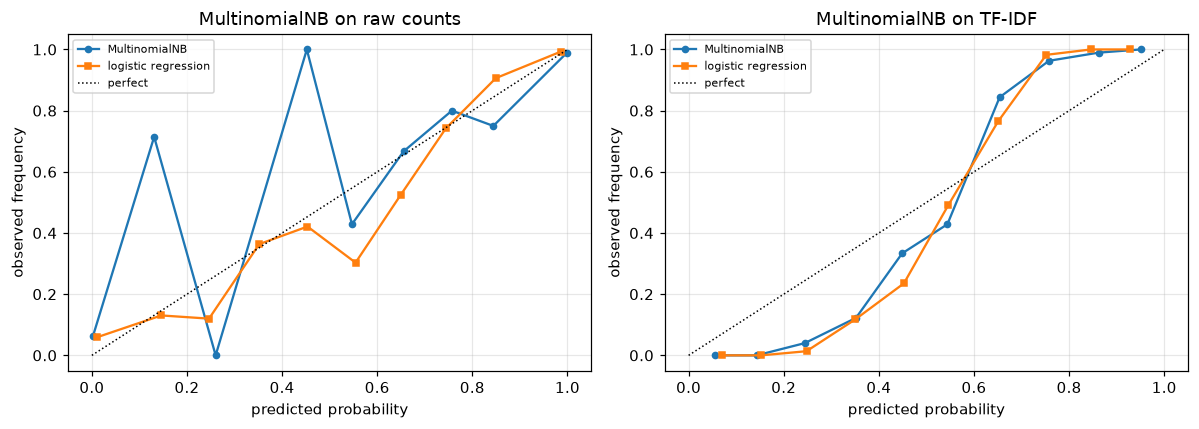

raw counts, bin occupancy - why the middle of that curve is noise:

  bin             documents
  --------------------------
  [0.0, 0.1)          321
  [0.1, 0.2)            7
  [0.2, 0.3)            1
  [0.3, 0.4)            0
  [0.4, 0.5)            2
  [0.5, 0.6)           14
  [0.6, 0.7)            3
  [0.7, 0.8)            5
  [0.8, 0.9)            4
  [0.9, 1.0)          351

  672 of 708 documents (95%) sit in the two end bins.

The model has essentially no vocabulary between 'definitely not' and 'definitely'.
The wiggles in the middle of the curve are computed from a handful of documents each
and should not be interpreted - which is why a calibration plot without bin counts
is a misleading chart.


In [24]:
# The calibration curve, with bin sizes shown - the honest version.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (vname, title) in zip(axes, [("raw counts", "MultinomialNB on raw counts"),
                                     ("TF-IDF", "MultinomialNB on TF-IDF")]):
    p_nb = store[(vname, "MultinomialNB")]
    p_lr = store[(vname, "logistic regression")]
    for label, p, style in [("MultinomialNB", p_nb, "o-"), ("logistic regression", p_lr, "s-")]:
        frac, mean_pred = calibration_curve(te_b.target, p, n_bins=10, strategy="uniform")
        ax.plot(mean_pred, frac, style, label=label, markersize=4)
    ax.plot([0, 1], [0, 1], "k:", lw=1, label="perfect")
    ax.set(xlabel="predicted probability", ylabel="observed frequency", title=title)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

p_nb = store[("raw counts", "MultinomialNB")]
frac, mean_pred = calibration_curve(te_b.target, p_nb, n_bins=10, strategy="uniform")
edges = np.linspace(0, 1, 11)
idx = np.clip(np.digitize(p_nb, edges) - 1, 0, 9)
sizes = np.bincount(idx, minlength=10)
print("raw counts, bin occupancy - why the middle of that curve is noise:\n")
print(f"  {'bin':<14} {'documents':>10}")
print("  " + "-" * 26)
for k in range(10):
    print(f"  [{edges[k]:.1f}, {edges[k+1]:.1f})   {sizes[k]:>10}")
print()
print(f"  {sizes[0] + sizes[-1]} of {sizes.sum()} documents "
      f"({(sizes[0] + sizes[-1]) / sizes.sum():.0%}) sit in the two end bins.")
print()
print("The model has essentially no vocabulary between 'definitely not' and 'definitely'.")
print("The wiggles in the middle of the curve are computed from a handful of documents each")
print("and should not be interpreted - which is why a calibration plot without bin counts")
print("is a misleading chart.")

## 3.2 Can it be fixed?

Yes — by refusing to trust the probabilities and fitting a correction on held-out data.
`CalibratedClassifierCV` learns a mapping from NB's scores to real probabilities, either with
a sigmoid (Platt scaling) or isotonic regression (NB-00 §7, NB-02 Part 3).

This cannot repair the ranking, because it only applies a monotonic transform — but the ranking
was never the problem.

In [25]:
A_c = CountVectorizer().fit(tr_b.data)
Xc, Tc = A_c.transform(tr_b.data), A_c.transform(te_b.data)

print(f"{'model':<38} {'acc':>7} {'AUC':>7} {'Brier':>8} {'log-loss':>10}")
print("-" * 74)
for label, model in [
    ("MultinomialNB (raw)", MultinomialNB()),
    ("+ CalibratedClassifierCV, sigmoid",
     CalibratedClassifierCV(MultinomialNB(), method="sigmoid", cv=5)),
    ("+ CalibratedClassifierCV, isotonic",
     CalibratedClassifierCV(MultinomialNB(), method="isotonic", cv=5)),
    ("logistic regression (reference)", LogisticRegression(max_iter=3000)),
]:
    model.fit(Xc, tr_b.target)
    p = model.predict_proba(Tc)[:, 1]
    print(f"{label:<38} {accuracy_score(te_b.target, model.predict(Tc)):>7.4f} "
          f"{roc_auc_score(te_b.target, p):>7.4f} "
          f"{brier_score_loss(te_b.target, p):>8.4f} "
          f"{log_loss(te_b.target, p):>10.4f}")

print()
print("Calibration collapses the log-loss while leaving AUC essentially untouched - which is")
print("the clearest possible demonstration that RANKING and CALIBRATION are separate")
print("properties. The model always knew the right order; it could not express the right")
print("degree of belief.")
print()
print("Cost: CalibratedClassifierCV refits the model once per CV fold. On a model this cheap")
print("that is irrelevant. On an SVM (NB-06 section 3.2) it is a ~6x tax.")

model                                      acc     AUC    Brier   log-loss
--------------------------------------------------------------------------
MultinomialNB (raw)                     0.9407  0.9839   0.0477     0.5265
+ CalibratedClassifierCV, sigmoid       0.9421  0.9835   0.0486     0.1819
+ CalibratedClassifierCV, isotonic      0.9421  0.9834   0.0445     0.1590
logistic regression (reference)         0.8856  0.9624   0.0754     0.3117

Calibration collapses the log-loss while leaving AUC essentially untouched - which is
the clearest possible demonstration that RANKING and CALIBRATION are separate
properties. The model always knew the right order; it could not express the right
degree of belief.

Cost: CalibratedClassifierCV refits the model once per CV fold. On a model this cheap
that is irrelevant. On an SVM (NB-06 section 3.2) it is a ~6x tax.


## 3.3 Why the prior stops working

§1.8 promised that you can restate the class prior at deployment without refitting. That is
true of the arithmetic. Whether it *changes any predictions* depends on how large the
likelihood term is — and §3.1 just measured that as being in the hundreds.

In [26]:
print("A prior shift adds a constant to the log-odds. How does that compare to what is")
print("already there?\n")

for vname, vec in [("raw counts", CountVectorizer()), ("TF-IDF", TfidfVectorizer())]:
    A = vec.fit_transform(tr_b.data)
    B = vec.transform(te_b.data)
    m = MultinomialNB().fit(A, tr_b.target)
    lp = m.predict_log_proba(B)
    marg = lp[:, 1] - lp[:, 0]
    print(f"  {vname.upper()}   typical |log-odds| = {np.abs(marg).mean():.2f} "
          f"(median {np.median(np.abs(marg)):.2f})")
    for ratio in [2, 9, 99, 999]:
        shift = np.log(ratio)
        flipped = (np.sign(marg) != np.sign(marg - shift)).mean()
        print(f"    a {ratio:>3}:1 prior shift adds {shift:>5.2f} "
              f"-> flips {flipped:>6.1%} of predictions")
    print()

cvv = CountVectorizer()
Av = cvv.fit_transform(tr_b.data)
mm = MultinomialNB().fit(Av, tr_b.target)
lpv = mm.predict_log_proba(cvv.transform(te_b.data))
need = np.median(np.abs(lpv[:, 1] - lpv[:, 0]))
print(f"On raw counts, moving half the predictions would need a log-odds shift of ~{need:.0f},")
print(f"i.e. prior odds of about 10^{need / np.log(10):.0f} : 1.")
print()
print("So the textbook advice - 'just restate the prior at deployment' - is arithmetically")
print("true and practically INERT on raw counts. The likelihood shouts so loudly that the")
print("prior cannot be heard.")
print()
print("On TF-IDF the same advice works, and in fact works dangerously well: the log-odds")
print("there are around 2, so a 9:1 prior genuinely reshapes the output.")
print()
print("The lesson generalises past Naive Bayes: whenever you plan to correct a model with an")
print("additive score adjustment - a threshold, a prior, a business rule - measure the scale")
print("of the scores FIRST. An adjustment that is small relative to the score distribution")
print("does nothing at all.")

A prior shift adds a constant to the log-odds. How does that compare to what is
already there?

  RAW COUNTS   typical |log-odds| = 160.82 (median 40.18)
    a   2:1 prior shift adds  0.69 -> flips   2.3% of predictions
    a   9:1 prior shift adds  2.20 -> flips   3.7% of predictions
    a  99:1 prior shift adds  4.60 -> flips   5.1% of predictions
    a 999:1 prior shift adds  6.91 -> flips   6.8% of predictions

  TF-IDF   typical |log-odds| = 1.94 (median 1.92)
    a   2:1 prior shift adds  0.69 -> flips   8.5% of predictions
    a   9:1 prior shift adds  2.20 -> flips  31.6% of predictions
    a  99:1 prior shift adds  4.60 -> flips  55.4% of predictions
    a 999:1 prior shift adds  6.91 -> flips  56.2% of predictions

On raw counts, moving half the predictions would need a log-odds shift of ~40,
i.e. prior odds of about 10^17 : 1.

So the textbook advice - 'just restate the prior at deployment' - is arithmetically
true and practically INERT on raw counts. The likelihood shouts s

In [27]:
# The same point, as accuracy under each assumed prior.
print(f"{'assumed prior':<28} {'raw counts':>12} {'TF-IDF':>10}")
print("-" * 52)
for label, prior in [("fitted from training", None),
                     ("uniform 50/50", [0.5, 0.5]),
                     ("9:1 toward atheism", [0.9, 0.1]),
                     ("1:9 toward graphics", [0.1, 0.9])]:
    row = []
    for vec in [CountVectorizer(), TfidfVectorizer()]:
        A = vec.fit_transform(tr_b.data)
        B = vec.transform(te_b.data)
        m = MultinomialNB(class_prior=prior).fit(A, tr_b.target)
        row.append(accuracy_score(te_b.target, m.predict(B)))
    print(f"{label:<28} {row[0]:>12.4f} {row[1]:>10.4f}")

print()
print("Raw counts barely notice a 9:1 prior. TF-IDF loses a quarter of its accuracy to the")
print("same change. Same model, same data, same argument - opposite conclusions, decided")
print("entirely by which vectorizer you used.")

assumed prior                  raw counts     TF-IDF
----------------------------------------------------
fitted from training               0.9407     0.9280
uniform 50/50                      0.9435     0.9449
9:1 toward atheism                 0.9364     0.6681
1:9 toward graphics                0.9449     0.7232

Raw counts barely notice a 9:1 prior. TF-IDF loses a quarter of its accuracy to the
same change. Same model, same data, same argument - opposite conclusions, decided
entirely by which vectorizer you used.


## 3.4 Imbalanced classes, and what ComplementNB fixes

Rennie et al. (2003) catalogued Naive Bayes' systematic problems on text. One is that with
skewed class sizes, the large classes' word distributions are estimated from far more data and
end up dominating. **ComplementNB** fits each class's parameters from the *complement* — all
the documents **not** in that class — which is a much more stable estimate for a rare class.

In [28]:
CATS6 = ["alt.atheism", "comp.graphics", "sci.med", "soc.religion.christian",
         "rec.sport.hockey", "talk.politics.guns"]
tr6 = fetch_20newsgroups(subset="train", categories=CATS6, remove=REMOVE,
                         random_state=RANDOM_STATE)
te6 = fetch_20newsgroups(subset="test", categories=CATS6, remove=REMOVE,
                         random_state=RANDOM_STATE)
names6 = list(tr6.target_names)

rng = np.random.default_rng(RANDOM_STATE)
fracs = [1.0, 1.0, 1.0, 0.30, 0.10, 0.04]
keep = []
for c, f in enumerate(fracs):
    idx = np.where(np.array(tr6.target) == c)[0]
    keep.extend(rng.choice(idx, max(8, int(len(idx) * f)), replace=False))
keep = np.array(sorted(keep))
docs6 = [tr6.data[i] for i in keep]
y6 = np.array(tr6.target)[keep]
counts6 = np.bincount(y6, minlength=6)

print("Deliberately imbalanced training set (the TEST set is untouched):")
for c, n in enumerate(counts6):
    print(f"  {names6[c]:<26} {n:>5}")
print(f"  imbalance ratio {counts6.max() / counts6.min():.0f}:1")

v6 = TfidfVectorizer()
A6 = v6.fit_transform(docs6)
B6 = v6.transform(te6.data)

print(f"\n{'model':<24} {'accuracy':>10} {'macro F1':>10}")
print("-" * 46)
preds = {}
for label, model in [("MultinomialNB", MultinomialNB()),
                     ("ComplementNB", ComplementNB()),
                     ("logistic regression", LogisticRegression(max_iter=3000))]:
    model.fit(A6, y6)
    preds[label] = model.predict(B6)
    print(f"{label:<24} {accuracy_score(te6.target, preds[label]):>10.4f} "
          f"{f1_score(te6.target, preds[label], average='macro'):>10.4f}")

print(f"\nper-class recall on the test set:")
print(f"  {'class':<26} {'train n':>8} {'MultinomialNB':>14} {'ComplementNB':>14}")
print("  " + "-" * 66)
yt6 = np.array(te6.target)
for c in range(6):
    rm = (preds["MultinomialNB"][yt6 == c] == c).mean()
    rc = (preds["ComplementNB"][yt6 == c] == c).mean()
    print(f"  {names6[c]:<26} {counts6[c]:>8} {rm:>14.2f} {rc:>14.2f}")

print()
print("ComplementNB is clearly better on macro F1, and the per-class table shows where it")
print("comes from: MultinomialNB never predicts ANY of the three starved classes, while")
print("ComplementNB at least finds a quarter of sci.med.")
print()
print("Now the honest part: both are bad. The two rarest classes are still near zero recall,")
print("and overall accuracy is around 0.5. ComplementNB is a better ESTIMATOR under")
print("imbalance, not a solution to imbalance. The real fixes - resampling, class weights,")
print("threshold selection - are NB-11.")

Deliberately imbalanced training set (the TEST set is untouched):
  alt.atheism                  480
  comp.graphics                584
  rec.sport.hockey             600
  sci.med                      178
  soc.religion.christian        59
  talk.politics.guns            21
  imbalance ratio 29:1

model                      accuracy   macro F1
----------------------------------------------
MultinomialNB                0.4459     0.3092
ComplementNB                 0.5015     0.4080
logistic regression          0.4817     0.3797

per-class recall on the test set:
  class                       train n  MultinomialNB   ComplementNB
  ------------------------------------------------------------------
  alt.atheism                     480           0.82           0.89
  comp.graphics                   584           0.93           0.94
  rec.sport.hockey                600           0.97           0.95
  sci.med                         178           0.00           0.25
  soc.religion.christ

## 3.5 Speed, which is the actual reason to use it

Fitting Naive Bayes is one sparse column-sum per class. There is no iteration, so it is not
merely fast — it is in a different complexity class from anything that optimises a loss.

In [29]:
v_sp = TfidfVectorizer()
A_sp = v_sp.fit_transform(tr6.data)
B_sp = v_sp.transform(te6.data)
y_sp = tr6.target

print(f"{A_sp.shape[0]:,} documents x {A_sp.shape[1]:,} features, {len(names6)} classes\n")
print(f"{'model':<28} {'fit (s)':>9} {'vs NB':>9} {'test acc':>10}")
print("-" * 60)
t_nb = None
fit, acc = {}, {}
for label, model in [
    ("MultinomialNB", MultinomialNB()),
    ("ComplementNB", ComplementNB()),
    ("SGDClassifier (hinge)", SGDClassifier(random_state=RANDOM_STATE)),
    ("LinearSVC", LinearSVC()),
    ("logistic regression", LogisticRegression(max_iter=3000)),
    ("random forest (200)", RandomForestClassifier(n_estimators=200,
                                                   random_state=RANDOM_STATE, n_jobs=-1)),
]:
    t0 = time.time()
    model.fit(A_sp, y_sp)
    t = time.time() - t0
    if t_nb is None:
        t_nb = t
    fit[label] = t
    acc[label] = accuracy_score(te6.target, model.predict(B_sp))
    print(f"{label:<28} {t:>9.3f} {t / t_nb:>8.0f}x {acc[label]:>10.4f}")

print()
print("Read both columns together, and note WHICH NB variant you are reading.\n")
print(f"  MultinomialNB : {acc['MultinomialNB']:.4f}, which the linear SVM beats by "
      f"{acc['LinearSVC'] - acc['MultinomialNB']:.3f}.")
print("                  On that row alone, NB is a baseline and nothing more.")
print(f"  ComplementNB  : {acc['ComplementNB']:.4f} - within "
      f"{acc['LinearSVC'] - acc['ComplementNB']:.3f} of the linear SVM, at about "
      f"{fit['LinearSVC'] / fit['ComplementNB']:.0f}x less fit time.")
print()
print("That second row changes the verdict. On multiclass text with uneven class sizes -")
print("which is most real text - the Rennie et al. correction from 3.4 is not a niche")
print("option, it is the one to reach for.")
print()
print("(The two NB variants both fit in ~10 ms, so which of them is nominally 'fastest'")
print("flips between runs. Do not read anything into a millisecond.)")
print()
print("Either way, the argument for NB is the same shape:")
print("  - Fast enough to fit inside a loop while you are still exploring.")
print("  - No scaling, no tuning to be reasonable, no convergence babysitting.")
print("  - If your expensive model cannot beat it, the problem is your FEATURES.")
print()
print("It also still wins outright in one setting: when the model must be retrained")
print("constantly on streaming data. MultinomialNB supports partial_fit, and updating counts")
print("is genuinely incremental in a way that refitting an SVM is not.")

3,403 documents x 40,008 features, 6 classes

model                          fit (s)     vs NB   test acc
------------------------------------------------------------
MultinomialNB                    0.013        1x     0.6976
ComplementNB                     0.013        1x     0.8119
SGDClassifier (hinge)            0.162       12x     0.8172
LinearSVC                        0.234       18x     0.8238
logistic regression              2.050      156x     0.7956
random forest (200)              6.996      531x     0.7386

Read both columns together, and note WHICH NB variant you are reading.

  MultinomialNB : 0.6976, which the linear SVM beats by 0.126.
                  On that row alone, NB is a baseline and nothing more.
  ComplementNB  : 0.8119 - within 0.012 of the linear SVM, at about 17x less fit time.

That second row changes the verdict. On multiclass text with uneven class sizes -
which is most real text - the Rennie et al. correction from 3.4 is not a niche
option, it is th

***
# Part 4 - Tough questions

***

### Q1. Naive Bayes and logistic regression are both linear classifiers. What is the actual difference?

<details><summary>Answer</summary>

**Generative vs discriminative — they model different things and fit by different means.**

| | Naive Bayes | Logistic regression |
|---|---|---|
| Models | $P(x \mid c)$ and $P(c)$, then applies Bayes' rule | $P(c \mid x)$ directly |
| Fitting | **Counting.** Closed form, one pass | **Optimisation.** Iterative, gradient-based |
| Feature correlation | Assumes it away | Learns weights *accounting* for it |
| Can generate data | Yes — sample from $P(x \mid c)$ | No |
| Speed | §3.5 measures ~100× faster | Slower |
| Calibration | Poor (§3.1) | Good — log-loss is a proper scoring rule |

§1.3 shows they produce the **same functional form**: a weighted sum of features plus an
intercept. NB just gets its weights by counting rather than by minimising a loss.

**The consequence that matters:** logistic regression, given two perfectly correlated features,
splits the weight between them. Naive Bayes gives each the full weight, counting the same
evidence twice — which is exactly what §1.7 demonstrates.

**Ng & Jordan (2002)** made the trade-off precise: NB has **higher asymptotic error** (its
assumption is wrong, and more data cannot fix a wrong model) but **converges faster** — it
approaches its ceiling in $O(\log n)$ examples versus $O(n)$. So NB tends to win on small
training sets and lose on large ones, and there is a crossover point.

</details>

***

### Q2. The independence assumption is clearly false for text. Why does the classifier work anyway?

<details><summary>Answer</summary>

**Because classification needs the argmax to be right, not the probabilities.**

The decision is $\arg\max_c P(c \mid x)$. If every class's score is wrong by a similar factor,
the comparison between them survives. Only *lopsided* errors flip a decision — and correlated
features tend to inflate all classes' scores in the same direction, because the correlated
words are correlated within every class.

§1.7 demonstrates it directly. Duplicating every feature 10× adds no information, yet:

| | k=1 | k=10 |
|---|---|---|
| accuracy | 0.9407 | 0.9393 |
| ROC-AUC | 0.9839 | 0.9823 |
| mean \|log-odds\| | 160.8 | **1608.1** |
| log-loss | 0.5265 | **1.3761** |

Confidence scales **exactly linearly** with the duplication factor while the ranking is
untouched. That is the whole phenomenon in one table.

**Domingos & Pazzani (1997)** proved NB is optimal under zero-one loss whenever the posterior
*ordering* is correct — a far weaker condition than the posteriors being correct. They also
showed NB is optimal for some dependent distributions, so dependence alone does not doom it.

**Do not over-learn this.** It says NB is a good *classifier* despite the assumption. It says
nothing good about its *probabilities*, which Part 3 shows are close to worthless untreated.

</details>

***

### Q3. What breaks if you set `alpha=0`, and why is a fix needed at all?

<details><summary>Answer</summary>

**One unseen word sets the entire class probability to zero.**

$P(w \mid c)$ is estimated by counting. If word $w$ never appeared in class $c$ in training,
the estimate is exactly 0. Since the score is a product, that single zero annihilates
everything — the other 199 words could all be overwhelming evidence for $c$ and it would not
matter. In log space, $\log 0 = -\infty$ and the class is eliminated permanently.

This is not rare. Vocabularies are large and Zipf-distributed, so most words are rare, and any
new document is very likely to contain a word some class never used. §1.4 measures **a large
share of the log-probability table at $-\infty$** with `alpha=0`, accuracy collapsing from
~0.94 to **0.6935**, and log-loss becoming literally infinite.

**The fix:** add a pseudocount $\alpha$ to every count.

$$ P(w \mid c) = \frac{\text{count}(w, c) + \alpha}{\sum_{w'}\text{count}(w', c) + \alpha n} $$

$\alpha=1$ is Laplace smoothing; $0 < \alpha < 1$ is Lidstone. Interpreted Bayesianly, it is a
Dirichlet prior — you are asserting you have seen every word $\alpha$ times before looking.

**Tune it.** It is a bias-variance dial: §1.4 shows $\alpha=100$ dragging everything toward
uniform (accuracy 0.7839), and §2.4 finds the optimum on real text **well below** the default
of 1.0. With a 30,000-word vocabulary, a full pseudocount per feature is a lot of invented
evidence.

sklearn makes `alpha=0` deliberately awkward — it requires `force_alpha=True` and still emits
a divide-by-zero warning. Take the hint.

</details>

***

### Q4. Why take logarithms? Give the concrete failure.

<details><summary>Answer</summary>

**float64 underflow.** The score is a product of hundreds of small probabilities.

§1.3 measures it: multiplying 0.01 by itself underflows to **exactly 0.0 after 162 factors**.
A 200-word document has ~200 factors. Every class then scores 0.0, and `argmax` returns class 0
regardless of the evidence — a silent, total failure that raises nothing.

Taking logs turns the product into a sum:

$$ \log P(c) + \sum_j x_j \log P(x_j \mid c) $$

Sums of ~200 numbers around $-7$ land near $-1400$, which float64 handles without difficulty.
The argmax is unchanged because $\log$ is monotonic.

**Two things worth adding:**

1. **It reveals the model's true shape.** That expression is an intercept plus a dot product —
   NB is a **linear classifier** (Q1). The log is not just numerical hygiene; it shows what the
   model actually is.
2. **Getting back to probabilities needs care.** Exponentiating $-1400$ underflows again. The
   standard trick is the **log-sum-exp**: subtract the maximum log-score before exponentiating,
   which cancels in the normalisation. `predict_log_proba` does this, which is why you should
   use it rather than `np.log(predict_proba(...))`.

</details>

***

### Q5. NB gives 0.97 accuracy and its `predict_proba` says 0.9999. Should you believe the second number?

<details><summary>Answer</summary>

**No. Believe the accuracy; ignore the probability.**

§3.1 measures NB on raw counts: **30.1% of documents scored exactly 0.0 or 1.0** in float64,
77% outside $[10^{-6}, 1-10^{-6}]$, and log-odds ranging from **−1459 to +12183**. For scale, a
well-calibrated binary model rarely exceeds ±6 (about 400:1).

**Why:** the log-odds is a sum over tokens. Correlated words each contribute their full weight
(Q2), so evidence is counted many times over. §3.1 shows the effect scaling with document
length — mean |log-odds| rising from 16 for short documents to over 1300 for long ones. The
model is not more certain about long documents; it is just adding up more double-counted terms.

**What to do:**

- **If you only need the decision or a ranking, nothing.** AUC is excellent; the ordering is
  fine.
- **If you need probabilities, calibrate.** §3.2 wraps NB in `CalibratedClassifierCV` and the
  log-loss collapses while AUC barely moves — proving the ranking was always right and only the
  scale was wrong.
- **Never threshold NB's raw probabilities at a "meaningful" value.** "Flag if $P > 0.99$"
  means nothing when 30% of documents score exactly 1.0.

**The measurement trap, which is the real lesson:** §3.1 shows **Brier score rating NB as
better calibrated than logistic regression** (0.0477 vs 0.0754) while log-loss rates it far
worse (0.5265 vs 0.3117). Brier is a bounded squared error, so a confident mistake costs at
most 1.0; log-loss is unbounded and punishes confident errors properly. **Use log-loss to
detect overconfidence.** If you had checked only Brier, you would have concluded the model was
fine.

</details>

***

### Q6. Which NB variant for which data, and what goes wrong if you pick wrong?

<details><summary>Answer</summary>

They differ only in the assumed form of $P(x_j \mid c)$.

| Variant | Assumes | For | Failure if misapplied |
|---|---|---|---|
| **MultinomialNB** | multinomial counts | word counts, TF-IDF | Rejects negative values (`ValueError`); treats scaled features as counts |
| **ComplementNB** | as above, fitted on each class's complement | imbalanced text | Little downside; often a free improvement (§3.4) |
| **BernoulliNB** | binary presence/absence | short text, binary features | Binarises at 0 by default — **§1.6 measures 0.6274 on breast cancer**, because every positive measurement becomes 1 |
| **GaussianNB** | a Gaussian per feature per class | continuous numeric | Needs a dense matrix — instant `MemoryError` on real text |

§1.6 measures both directions:

- **Continuous data** (breast cancer): GaussianNB **0.9385**, MultinomialNB 0.8981, BernoulliNB
  **0.6274**.
- **Text counts**: MultinomialNB **0.9407**, ComplementNB 0.9435, BernoulliNB 0.8347.

BernoulliNB loses ~11 points on text because it discards word *frequency*. That is a real
modelling choice, not a bug — on very short documents (tweets, subject lines) presence is
most of the signal and BernoulliNB can win.

**The trap worth naming:** MultinomialNB does not complain about continuous non-negative
features. It scored 0.8981 on breast cancer while treating "mean radius" as a word count. It
will not error, and it will not be right.

</details>

***

### Q7. Your spam filter was trained on data that was 50% spam. Live traffic is 5% spam. Fix it without retraining.

<details><summary>Answer</summary>

**Restate the prior** — and then check whether it did anything, because §3.3 shows it often
does not.

The prior enters the log-space score as one additive constant per class, so:

```python
model.set_params(class_prior=[0.95, 0.05])   # or refit with this
```

No re-counting is needed. This is a genuine advantage of a generative model: it separates
$P(c)$ from $P(x \mid c)$, so you can change your beliefs about class frequency independently
of what you learned about the words.

**Now the part most answers get wrong.** §3.3 measures whether it changes any predictions:

- **On raw counts**, typical |log-odds| is **160**. A 999:1 prior shift adds 6.9 and flips
  **6.8%** of predictions. Moving half of them would need prior odds around $10^{17}$:1. **The
  prior is inert** — the likelihood shouts too loudly to hear it.
- **On TF-IDF**, typical |log-odds| is **1.94**. A 9:1 shift flips **31.6%** and drops accuracy
  from 0.9280 to 0.6681. Here it works — and can easily do more harm than good.

Same model, same argument, opposite conclusions, decided by the vectorizer.

**So the complete answer is:** set the prior, then **measure the distribution of your log-odds**
to know whether the correction is meaningful. And if what you actually care about is the
precision/recall trade rather than the prior *per se*, tune the **decision threshold** on
validation data (NB-02 Part 3) — that works regardless of scale, because you are choosing the
cut point in the score distribution you actually have.

</details>

***

### Q8. You switch from `CountVectorizer` to `TfidfVectorizer` and accuracy drops 14 points. What happened?

<details><summary>Answer</summary>

**You changed the scale of the features without changing `alpha`, and `alpha` is a count.**

This is not hypothetical — §2.3 measures exactly this drop, and it is the most common way to
get Naive Bayes and TF-IDF wrong.

`alpha` is an **additive pseudocount** applied to every feature, per class:

$$ P(w \mid c) = \frac{\text{count}(w,c) + \alpha}{\sum_{w'}\text{count}(w',c) + \alpha n} $$

The two vectorizers produce values on completely different scales. §2.3 measures them:

| | median non-zero value | median column sum |
|---|---|---|
| `CountVectorizer` | 1.0 | 2.0 |
| `TfidfVectorizer` | 0.054 | **0.127** |

Adding `alpha=1.0` to a column that sums to 2.0 is a nudge. Adding it to a column that sums to
**0.127** is roughly **eight times the evidence you are smoothing** — the prior replaces the
data.

**The measured consequence:**

| alpha | raw counts | TF-IDF |
|---|---|---|
| 1.0 (sklearn's default) | 0.8103 | **0.6691** |
| 0.01 | 0.8389 | **0.8375** |

At the default, TF-IDF looks 14 points worse. At `alpha=0.01` the two are within 0.002. **The
representation was never the problem.** sklearn's default was chosen for counts, and nothing
warns you when you feed it something else.

**Three things to take away:**

1. **Never compare representations at a fixed hyperparameter.** You are measuring the
   interaction, not the representation. This generalises well beyond NB.
2. **If accuracy drops after a preprocessing change, retune before concluding.**
3. TF-IDF still earns its place for the reason §3.1 gives: L2 row normalisation caps how much
   evidence one document can accumulate, so typical |log-odds| falls from **160 to 1.94** and
   the probabilities become far less absurd. That benefit is real and separate from accuracy —
   though Q7 shows it also makes the prior dangerously powerful again.

Rennie et al. (2003) formalised these transforms as fixes for NB's "poor assumptions";
`ComplementNB` is that paper in scikit-learn.

</details>

***

### Q9. Why is 20 Newsgroups accuracy usually reported too high?

<details><summary>Answer</summary>

**The metadata.** Each post ships with Usenet headers, quoted reply text, and signature
footers. Headers can include a literal `Newsgroups:` field — the label. Even without it,
`Organization:` and `Subject:` are enormously predictive.

§2.1 measures it on the same model and documents:

| left in the text | test accuracy |
|---|---|
| everything (the default) | **0.8349** |
| headers removed | 0.7763 |
| headers + footers + quotes | **0.6691** |

**The metadata is worth ~0.17 accuracy — about 25% of the honest score.** `remove=` is not the
default, so the leaky number is what you get if you do not think about it.

**And `remove=` is not sufficient.** §2.6 finds residual leaks it does not catch, by the simple
expedient of reading the model's top evidence words. **Two of the four classes** turn out to be
detected primarily by a single author's signature block:

- **sci.med** — `geb@`, `n3jxp`, "chastity of the intellect": one poster's quotation, in **13%
  of that class's training documents**, 100% precise.
- **alt.atheism** — `bobbe`, `beauchaine`, `queens`, `bronx`, `sank`: another poster's song
  lyric, also 100% precise.

Both sit in the message *body*, so no `remove=` option touches them.

**The two cases differ in a way that matters**, and §2.6 measures it:

- The sci.med signature appears in **zero test documents** — that poster stopped before the
  test period. It did not inflate the score; it just spent model capacity on a token that
  predicts nothing at prediction time.
- The alt.atheism signature **does appear in test documents**. That is a genuine train/test
  leak: the same author on both sides of the split, and the model is rewarded for recognising
  him.

**The transferable lesson:** "I removed the obvious leak" is not "there is no leak". Read what
the model actually learned. Naive Bayes makes that easy — `feature_log_prob_` is a readable
evidence table — which is one of the better arguments for fitting it even when you plan to ship
something else.

</details>

***

### Q10. When would you actually deploy Naive Bayes in 2026?

<details><summary>Answer</summary>

Rarely as the final model, and that is fine — it earns its place elsewhere.

**Genuine cases:**

1. **As the baseline you fit first.** §3.5 measures it fitting in ~0.01s against ~1.3s for
   logistic regression on the same matrix. It needs no scaling, no tuning to be reasonable, and
   no convergence checks. If your expensive model cannot beat it, the problem is your features.
2. **Streaming / online learning.** `partial_fit` updates counts incrementally. Updating a
   count is genuinely $O(1)$; refitting an SVM is not.
3. **Very small training sets.** Ng & Jordan (2002): NB converges to its ceiling in $O(\log n)$
   examples. With 50 labelled documents it will often beat logistic regression outright.
4. **Extreme scale with a latency budget**, where a few points of accuracy are worth less than
   the compute.
5. **Where you must explain every decision.** `feature_log_prob_` is a readable per-word
   evidence table (§2.6) — no SHAP, no surrogate model.

**Where it is genuinely obsolete:** as a serious text classifier. A fine-tuned transformer, or
even a linear model over good embeddings, beats it comfortably on any benchmark you care about.

Note that §2.5 does *not* demonstrate this — NB comes out on top there, and §2.5 says plainly
why you should not believe it: NB was tuned and the others were not, on features chosen to suit
NB. That is worth remembering as a pattern. Most "our model wins" tables are built exactly that
way.

**The honest summary:** Naive Bayes is a superb *baseline* and a poor *model*, and knowing the
difference is more valuable than the algorithm.

</details>

***

### Q11. Your NB text classifier scores 0.95 in cross-validation and 0.70 in production. Give four explanations.

<details><summary>Answer</summary>

1. **Metadata leakage in evaluation** (Q9). Something in your training text is not available at
   prediction time, or does not mean the same thing — a header, a template, an internal ticket
   ID, a routing tag added *after* the label was assigned. This is the first thing to check
   because it is the most common and produces exactly this signature.
2. **Vectorizer fitted outside the pipeline.** If `TfidfVectorizer` was fitted on all the text
   before splitting, then the vocabulary and IDF weights saw the validation documents. §2.4
   keeps it inside the pipeline for this reason. Related: **words unseen in training are
   silently dropped** at prediction time, so a production vocabulary that has drifted loses
   signal without any error being raised.
3. **Vocabulary or topic drift.** Text ages fast — new products, new slang, new spam tactics.
   NB is especially exposed because it is *only* a word-frequency model. Note that this
   notebook's own test set is a later time period, which is why §2.5's CV-to-test gap is
   negative and expected.
4. **Class balance shifted.** The fitted prior encodes training frequencies. If production is
   5% spam and training was 50%, the prior is wrong — though Q7 and §3.3 show whether that
   *matters* depends on your vectorizer.

**The NB-specific diagnostic:** log the **fraction of tokens in each incoming document that are
out-of-vocabulary**. Rising OOV is the earliest possible warning of drift, it is one line to
compute, and no other model gives it to you this directly.

</details>

***

### Q12. Someone reports "our Naive Bayes model is 99.9% confident this email is spam". What do you say?

<details><summary>Answer</summary>

**"That number is not a probability. What is the accuracy at that operating point?"**

The reasoning, in order:

1. **NB's confidence is a double-counted sum, not a belief.** §3.1: 30% of documents score
   exactly 0.0 or 1.0 in float64; log-odds run to four digits. 99.9% is not the model's
   considered view — it is what you get when a few hundred correlated tokens each vote at full
   weight.
2. **It scales with document length, not with evidence quality.** §3.1 shows mean |log-odds|
   rising from 16 to over 1300 with length. A long email is *automatically* more "confident".
3. **The right question is empirical.** Take everything the model scored above 0.999 and
   measure what fraction were actually spam. That number is meaningful; the model's is not.
4. **If you need it to mean something, calibrate** (§3.2). `CalibratedClassifierCV` collapses
   log-loss while leaving AUC alone — the ranking was always fine.
5. **Check the right metric.** If they are monitoring probability quality with Brier score,
   §3.1 shows it will report NB as *better* than logistic regression while log-loss reports it
   as twice as bad. Use log-loss.

**The constructive framing:** NB's ranking is genuinely good. So use it as a ranking — sort by
score, choose a threshold on validation data by the cost of each error type (NB-02 Part 3), and
report *that* threshold's measured precision. Nobody needs the raw number to be a probability.

</details>

***

## Coding challenges

### Challenge 1 — build a spam filter, then break it

1. Load the SMS Spam Collection (Part 5, dataset 1). Build `TfidfVectorizer` →
   `MultinomialNB` and report accuracy, precision, recall and the confusion matrix.
2. **Choose the threshold deliberately.** A false positive (real message in the spam folder)
   is far worse than a false negative. Pick the threshold from that cost ratio rather than
   accepting 0.5, and quantify what it costs you in recall.
3. **Attack it.** Append 100 random dictionary words to each spam message — the "Bayesian
   poisoning" technique real spammers used. How far does accuracy fall, and why is NB
   specifically vulnerable? (Hint: what does the score do when you add many weakly
   ham-associated tokens?)
4. **Defend it.** Try `BernoulliNB` (presence, not frequency), a `max_features` cap, and
   `sublinear_tf`. Which defence helps most, and what does that tell you about the attack?

***

### Challenge 2 — find the crossover point

Ng & Jordan (2002) predict NB beats logistic regression on small samples and loses on large
ones. Measure it.

1. On 20 Newsgroups (4 categories, metadata removed), train both on 20, 50, 100, 200, 500,
   1000, 2000 documents. Use the same vectorizer, fitted per training subset.
2. Plot both learning curves on one axis with error bars over 10 random subsets.
3. **Find the crossover.** Where does logistic regression overtake NB? Does it exist?
4. Repeat with a much smaller vocabulary (`max_features=200`). Does the crossover move? Explain
   using the bias-variance argument — which model is bias-limited and which is variance-limited?

***

### Challenge 3 — quantify the independence violation

§1.2 shows word pairs co-occurring more than independence predicts. Turn that into a number
that predicts NB's failure.

1. For each class, compute pointwise mutual information $\log \frac{P(a,b)}{P(a)P(b)}$ for the
   top 200 words. Summarise the dependence with the mean.
2. Do it for several datasets: 20 Newsgroups, SMS spam, IMDB reviews, and a synthetic dataset
   from `make_classification(n_informative=k, n_redundant=0)`.
3. **Plot mean PMI against the NB-minus-logistic-regression accuracy gap.** Does more
   dependence predict a bigger gap?
4. Now plot mean PMI against the gap in **log-loss** rather than accuracy. Q2 predicts the
   relationship is much stronger for the second. Is it?

***
# Part 5 - Five datasets to practise on

Ordered so each one breaks a different assumption.

| # | Dataset | Size | The skill it forces | Difficulty |
|---|---|---|---|---|
| 1 | **SMS Spam Collection** | 5,574 × 1 text | The classic NB application; thresholding by cost | ★☆☆☆☆ |
| 2 | **20 Newsgroups (all 20)** | 18,846 docs | Multiclass at scale; the leakage discipline of §2.1 | ★★☆☆☆ |
| 3 | **IMDB reviews** | 50,000 docs | Long documents — where overconfidence is worst (§3.1) | ★★★☆☆ |
| 4 | **Iris / wine / breast cancer** | small, numeric | GaussianNB, and comparing against §1.6 | ★★☆☆☆ |
| 5 | **Reuters-21578 / RCV1** | 800k docs | Extreme imbalance and multi-label; ComplementNB's home | ★★★★★ |

In [30]:
print("bundled with sklearn, no download needed:\n")
print(f"  {'dataset':<20} {'rows':>7} {'cols':>6} {'classes':>8}")
print("  " + "-" * 44)
for label, loader in [("iris", load_iris), ("wine", load_wine),
                      ("breast cancer", load_breast_cancer)]:
    b = loader()
    print(f"  {label:<20} {b.data.shape[0]:>7} {b.data.shape[1]:>6} "
          f"{len(np.unique(b.target)):>8}")

full = fetch_20newsgroups(subset="train", remove=REMOVE, random_state=RANDOM_STATE)
full_te = fetch_20newsgroups(subset="test", remove=REMOVE, random_state=RANDOM_STATE)
print(f"\n  20 newsgroups (all 20) : {len(full.data):,} train + {len(full_te.data):,} test "
      f"= {len(full.data) + len(full_te.data):,} documents, "
      f"{len(full.target_names)} classes  [cached]")

print("\nGaussianNB on the three numeric datasets, as a starting point:")
for label, loader in [("iris", load_iris), ("wine", load_wine),
                      ("breast cancer", load_breast_cancer)]:
    X, y = loader(return_X_y=True)
    s = cross_val_score(GaussianNB(), X, y, cv=skf).mean()
    print(f"  {label:<20} {s:.4f}")
print()
print("SMS Spam, IMDB and Reuters are downloads; loaders are in the briefs below.")

bundled with sklearn, no download needed:

  dataset                 rows   cols  classes
  --------------------------------------------
  iris                     150      4        3
  wine                     178     13        3
  breast cancer            569     30        2

  20 newsgroups (all 20) : 11,314 train + 7,532 test = 18,846 documents, 20 classes  [cached]

GaussianNB on the three numeric datasets, as a starting point:
  iris                 0.9467
  wine                 0.9719
  breast cancer        0.9385

SMS Spam, IMDB and Reuters are downloads; loaders are in the briefs below.


### 1. SMS Spam Collection — the classic

```python
import pandas as pd
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
sms = pd.read_csv(url, sep="\t", header=None, names=["label", "message"])
```

5,574 real SMS messages, ~13% spam. This is the application NB was famous for.

1. Build `TfidfVectorizer` → `MultinomialNB`. Report accuracy **and** the confusion matrix.
   Why is accuracy nearly useless at 13% positives (NB-00 §6)?
2. Tune `alpha` by cross-validation. Compare against the default 1.0 — does §2.4's finding
   (that the optimum is well below 1) hold on much shorter documents?
3. Compare `MultinomialNB` against `BernoulliNB`. SMS messages are short, so Q6 predicts
   BernoulliNB should do relatively better here than on newsgroup posts. Does it?
4. Choose the threshold from the cost ratio, not 0.5. If a false positive is 10× worse than a
   false negative, where should it sit, and what does that cost in recall?
5. Plot a calibration curve. Are the probabilities as extreme as §3.1's? Short documents mean
   fewer terms in the sum — predict the answer before you run it.

***

### 2. 20 Newsgroups, all twenty — scale up

```python
train = fetch_20newsgroups(subset="train", remove=("headers", "footers", "quotes"))
```

The full corpus: 18,846 documents, 20 classes, several near-duplicates by design.

1. Reproduce §2.1's leakage comparison on all 20 classes. Is the gap bigger or smaller than on
   four, and can you explain why before checking?
2. Which class pairs does the confusion matrix confuse? Group them by theme
   (`comp.*`, `talk.politics.*`). Is NB confused by *topics* or by *vocabulary*?
3. Compare `MultinomialNB` against `ComplementNB` — class sizes are mildly uneven here. Does
   §3.4's advantage appear at this milder imbalance?
4. Tune `alpha` and `min_df` together. With 20 classes and a much bigger vocabulary, does the
   best `alpha` move relative to §2.4?
5. Print the top-10 evidence words per class (§2.6). Hunt for more author signatures. There are
   others besides the sci.med one.

***

### 3. IMDB reviews — long documents, maximum overconfidence

```python
from sklearn.datasets import load_files   # after downloading and untarring aclImdb
# https://ai.stanford.edu/~amaas/data/sentiment/
```

50,000 movie reviews, balanced, and **much longer** than newsgroup posts.

1. Fit `MultinomialNB` on raw counts. Measure the log-odds distribution as §3.1 does. Longer
   documents should mean even more extreme confidence — quantify it.
2. Plot mean |log-odds| against document length. Is the relationship linear, as §3.1's
   argument predicts?
3. Compare Brier score against log-loss for NB and logistic regression. Does §3.1's finding —
   that Brier hides what log-loss reveals — reproduce on a balanced dataset?
4. Add bigrams (`ngram_range=(1,2)`). Sentiment depends on negation ("not good"), which
   unigrams cannot represent. How much does it help, and does it make the independence
   violation better or worse?
5. Calibrate with `CalibratedClassifierCV` and re-measure. How much of the log-loss gap closes?

***

### 4. Iris, wine, breast cancer — GaussianNB and its assumption

```python
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
```

Small, numeric, continuous — GaussianNB's territory.

1. Fit `GaussianNB` on all three. Compare against logistic regression and a random forest.
   NB should be competitive on iris and clearly behind on breast cancer — why?
2. **Check the Gaussian assumption.** Plot a histogram of each feature per class. How many are
   plausibly normal? Try a log or Box-Cox transform on the skewed ones and re-fit.
3. Reproduce §1.6's variant table yourself and confirm BernoulliNB's collapse. Then change
   `binarize=` to each feature's median and watch it recover. What does that tell you about
   the default?
4. Wine has 13 correlated chemical measurements. Compute the correlation matrix, then compare
   NB against logistic regression. Does Q2's prediction — similar accuracy, much worse
   log-loss — hold on numeric data?

***

### 5. Reuters / RCV1 — extreme imbalance

```python
from sklearn.datasets import fetch_rcv1
rcv1 = fetch_rcv1()          # ~800k documents, 103 labels; a large download
```

Real-world text at scale, with severe class imbalance and **multi-label** targets.

1. Pick five labels ranging from common to very rare. Compare `MultinomialNB` against
   `ComplementNB` on macro F1. §3.4 predicts the gap widens with imbalance — measure it.
2. This is multi-label: a document can carry several. Wrap in `OneVsRestClassifier` and
   evaluate per-label rather than by accuracy.
3. Time NB against logistic regression and `SGDClassifier` at this scale. §3.5's ratio was
   measured on 3,000 documents — does it hold at 800,000?
4. Use `partial_fit` to train NB in minibatches without loading everything into memory. This is
   the setting where NB genuinely wins (Q10) — demonstrate it.
5. For the rarest labels, does *any* model beat predicting the majority? If not, say so
   plainly and read NB-11.

***
# Part 6 - Reading the literature

Naive Bayes has an unusually satisfying literature, because the interesting papers are not
about the algorithm — they are about **why something so wrong works so well**. That question
turns out to be deeper than the method.

## Start here

**1. [On the Optimality of the Simple Bayesian Classifier under Zero-One Loss](https://link.springer.com/article/10.1023/A:1007413511361)** —
Pedro Domingos & Michael Pazzani, *Machine Learning* 29:103–130, 1997.
> **The paper that answers the obvious objection.** Everyone notices the independence
> assumption is false; this explains why the classifier survives it. The key move is separating
> *correct probability estimates* from *correct argmax* — NB is optimal under zero-one loss
> whenever the posterior ordering is right, which is far weaker. §1.7 and Q2 are this paper.

**2. [Tackling the Poor Assumptions of Naive Bayes Text Classifiers](https://people.csail.mit.edu/jrennie/papers/icml03-nb.pdf)** —
Jason Rennie, Lawrence Shih, Jaime Teevan & David Karger, ICML 2003. **Free.**
> **The practical one, and the one that changed the defaults.** A systematic catalogue of what
> goes wrong — skewed class sizes, word-frequency effects, long documents — with a concrete fix
> for each. `ComplementNB` in scikit-learn is this paper. Read it before you tune anything;
> §3.4 and Q8 come from it.

**3. [On Discriminative vs. Generative Classifiers](https://papers.nips.cc/paper_files/paper/2001/hash/7b7a53e239400a13bd6be6c91c4f6c4e-Abstract.html)** —
Andrew Ng & Michael Jordan, NeurIPS 2001/2002. **Free.**
> The Naive Bayes vs logistic regression comparison, done properly. Same linear form, different
> fitting, different asymptotics: NB has higher asymptotic error but reaches its ceiling in
> $O(\log n)$ examples rather than $O(n)$. This is the source of "NB wins on small data" — and
> the paper is where Q1 and Challenge 2 come from.

## The paper behind each section

| Section | Source | Free? |
|---|---|---|
| 1.1 — Bayes' rule as a classifier | Hastie, Tibshirani & Friedman, *ESL* §6.6.3 — [free PDF](https://hastie.su.domains/ElemStatLearn/) | ✅ |
| 1.2, 1.7 — **why the false assumption survives** | **Domingos & Pazzani**, *Machine Learning* **1997** | 🔍 |
| 1.4 — smoothing | **Chen & Goodman**, *An Empirical Study of Smoothing Techniques for Language Modeling*, Harvard TR-10-98, **1998** | 🔍 |
| 1.6 — Multinomial vs Bernoulli, compared properly | **McCallum & Nigam**, *A Comparison of Event Models for Naive Bayes Text Classification*, AAAI workshop **1998** — [pdf](https://www.cs.cmu.edu/~knigam/papers/multinomial-aaaiws98.pdf) | ✅ |
| 2.1, 2.6 — text leakage in practice | **Rennie et al.**, ICML **2003**, and scikit-learn's own [20newsgroups notes](https://scikit-learn.org/stable/datasets/real_world.html#newsgroups-dataset) | ✅ |
| 3.1–3.2 — **calibration, and which metric detects it** | **Niculescu-Mizil & Caruana**, *Predicting Good Probabilities with Supervised Learning*, ICML **2005** — [pdf](https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf) | ✅ |
| 3.1 — why log-loss and not Brier | **Gneiting & Raftery**, *Strictly Proper Scoring Rules*, JASA 102, **2007** | 🔍 |
| 3.4 — ComplementNB | **Rennie et al.**, ICML **2003** — [pdf](https://people.csail.mit.edu/jrennie/papers/icml03-nb.pdf) | ✅ |
| Q1, Challenge 2 — generative vs discriminative | **Ng & Jordan**, NeurIPS **2002** | ✅ |
| Q10 — the original spam filter | **Sahami, Dumais, Heckerman & Horvitz**, *A Bayesian Approach to Filtering Junk E-Mail*, AAAI workshop **1998** | 🔍 |
| Challenge 1 — attacking a Bayesian filter | **Graham**, *A Plan for Spam*, **2002** — [essay](http://www.paulgraham.com/spam.html) | ✅ |

**Legend:** ✅ free at the link · 🔍 search the exact title on
[Google Scholar](https://scholar.google.com)

### If you read only one

**Domingos & Pazzani (1997).** Not because you will use Naive Bayes, but because it teaches the
most transferable idea in this notebook: *a model can be wrong about the world and still right
about the decision*. Once you have that distinction you will start noticing it everywhere —
in calibration, in ranking metrics, in every argument about whether a model "understands"
anything.

Then read **Rennie et al. (2003)** for the engineering, and **Ng & Jordan (2002)** for the
comparison you will be asked about in interviews.

***
# Appendix

| Symptom | Cause | Fix |
|---|---|---|
| `ValueError: Negative values in data` | `MultinomialNB` on scaled or centred features | Use `GaussianNB`, or `MinMaxScaler`; never `StandardScaler` before MultinomialNB |
| Accuracy collapses, log-loss is infinite | `alpha=0` — unseen words give $\log 0 = -\infty$ (§1.4) | Any `alpha > 0`; tune it, default 1.0 |
| `predict_proba` returns only 0.0 and 1.0 | Overconfidence from double-counted evidence (§3.1) | Expected. Calibrate (§3.2), or use the ranking only |
| Brier says calibrated, log-loss says awful | Brier is bounded; only log-loss punishes confident errors (§3.1) | Use log-loss to detect overconfidence |
| `MemoryError` on text | `GaussianNB` needs a dense matrix (§1.6) | Use `MultinomialNB` / `ComplementNB`, which take sparse input |
| BernoulliNB is far worse than expected | Default `binarize=0.0`, so all-positive features become all-ones (§1.6) | Set `binarize` to a real threshold, or use the right variant |
| Rare classes never predicted | Large classes dominate the estimates (§3.4) | `ComplementNB`; then NB-11 for the real fixes |
| Suspiciously high accuracy on 20 Newsgroups | Metadata leakage (§2.1) | `remove=("headers", "footers", "quotes")` — **and** read the evidence words (§2.6) |
| CV great, production poor | Vectorizer fitted outside the pipeline, or vocabulary drift (Q11) | Keep the vectorizer inside the `Pipeline`; monitor OOV rate |
| Changing `class_prior` does nothing | The likelihood term dwarfs it (§3.3) | Measure your log-odds scale; tune the threshold instead |
| Evidence words are names, IDs or boilerplate | The model learned an author or a template, not the topic (§2.6) | Strip them; then ask what else you have not looked at |
| Every prediction is class 0 | Underflow — you multiplied probabilities instead of adding logs (§1.3) | Use `predict_log_proba`; never `np.log(predict_proba(...))` |

## Checklist for shipping a Naive Bayes model

Everything in the Foundations checklist, plus:

- [ ] Is the **vectorizer inside the Pipeline**, so it is re-fitted per CV fold?
- [ ] Was `alpha` **tuned**, not left at 1.0? (§2.4 finds the optimum well below the default.)
- [ ] Have I read the **top evidence words per class** and confirmed they are about the topic
      rather than an author, a template or an artifact?
- [ ] Am I using the **right variant** for my feature type (§1.6)?
- [ ] If I report probabilities: are they **calibrated**, and did I check with **log-loss**
      rather than Brier?
- [ ] Do I know the **scale of my log-odds**, so I know whether a prior or threshold adjustment
      will do anything (§3.3)?
- [ ] Am I monitoring the **out-of-vocabulary rate** in production as a drift alarm?
- [ ] For imbalanced classes: `ComplementNB` tried, and macro F1 reported rather than accuracy?
- [ ] Have I compared against **logistic regression and a linear SVM**, so I know what the
      speed is costing me?

## Where to go next

| Notebook | Why it follows |
|---|---|
| [`logistic_regression_zero_to_hero.ipynb`](logistic_regression_zero_to_hero.ipynb) | The discriminative twin. Same linear form, different fit, honest probabilities — Q1 is the comparison in full. |
| `pca_zero_to_hero.ipynb` | The next notebook in the series, and the other place where a "wrong" simplifying assumption buys enormous tractability. |
| `imbalanced_classification_zero_to_hero.ipynb` | §3.4 showed ComplementNB helping and still leaving the rare classes near zero recall. This is the fix. |
| [`svm_zero_to_hero.ipynb`](svm_zero_to_hero.ipynb) | The model that beat NB in §2.5, and still the strong choice for sparse text. |

See [`README.md`](README.md) for the full roster, the reading order and the suggested paths.